# Comparative Evaluation of SMILES Validators

This notebook provides a publication-quality comparative analysis of SMILES string validators:
- **YACC** (ours): LALR(1) grammar-based parser with Hückel aromaticity and valency checks
- **RDKit**: Industry-standard cheminformatics toolkit
- **PartialSMILES**: Incremental SMILES parser
- **PySMILES**: Python SMILES reader with graph construction
- **MolVS**: Molecule Validation and Standardization (RDKit-based)

## Datasets
| Dataset | Source | Molecules | Domain |
|---------|--------|-----------|--------|
| QM9 | Ramakrishnan et al. 2014 | ~134K | Small organic (≤9 heavy atoms) |
| ZINC250k | Irwin & Shoichet 2005 | ~249K | Drug-like commercial compounds |
| MOSES | Polykovskiy et al. 2020 | ~1.58M | Drug-like (ZINC Clean Leads subset) |
| Tox21 | Huang et al. 2016 | ~7.8K | Toxicology assays |
| MUV | Rohrer & Baumann 2009 | ~93K | Maximum Unbiased Validation |
| ClinTox | Gayvert et al. 2016 | ~1.5K | Clinical trial toxicity |
| SIDER | Kuhn et al. 2016 | ~1.4K | Side effect resource |
| Mutagenicity | Hansen et al. 2009 | ~4.3K | Ames mutagenicity |
| Invalid (synthetic) | This work | 50 | Systematically constructed invalid SMILES |
| Ground Truth | This work | 126 | Hand-labeled valid/invalid |

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter, defaultdict
from scipy import stats

from src import validate_smiles, parse_smiles
from rdkit import Chem
from rdkit import RDLogger
import partialsmiles as ps
import pysmiles
from molvs import validate_smiles as molvs_validate

# Suppress RDKit warnings for cleaner output
RDLogger.logger().setLevel(RDLogger.ERROR)

sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

SEED = 42
np.random.seed(SEED)

# ── Sample size per large dataset (increase for final paper) ──
SAMPLE_SIZE = 10_000

print('Setup complete.')

Setup complete.


Parser debugging for SmilesParser written to parser.out


## 1. Validator Definitions

In [2]:
def validate_rdkit(mol: str) -> bool:
    try:
        return Chem.MolFromSmiles(mol) is not None
    except:
        return False

def validate_partialsmiles(mol: str) -> bool:
    try:
        ps.ParseSmiles(mol, partial=False)
        return True
    except:
        return False

def validate_pysmiles(mol: str) -> bool:
    try:
        pysmiles.read_smiles(mol)
        return True
    except:
        return False

def validate_molvs(mol: str) -> bool:
    try:
        errors = molvs_validate(mol)
        return len(errors) == 0
    except:
        return False

def validate_yacc(mol: str) -> bool:
    status, _ = validate_smiles(mol)
    return status

def validate_yacc_detail(mol: str) -> tuple:
    """Returns (bool, error_string) for detailed analysis."""
    status, err = validate_smiles(mol)
    return status, str(err) if err else None

VALIDATORS = {
    'YACC': validate_yacc,
    'RDKit': validate_rdkit,
    'PartialSMILES': validate_partialsmiles,
    'PySMILES': validate_pysmiles,
    'MolVS': validate_molvs,
}

print(f'Defined {len(VALIDATORS)} validators.')

Defined 5 validators.


## 2. Dataset Loading

In [3]:
def load_dataset(path, smiles_col, name, sample_n=None):
    """Load a CSV and extract SMILES, optionally sampling."""
    df = pd.read_parquet(path)
    if smiles_col not in df.columns:
        raise ValueError(f"Column '{smiles_col}' not found. Available: {list(df.columns)}")
    smiles = df[smiles_col].dropna().str.strip().drop_duplicates().reset_index(drop=True)
    # Filter out extremely long SMILES (likely data artifacts)
    smiles = smiles[smiles.str.len() < 300].reset_index(drop=True)
    if sample_n and len(smiles) > sample_n:
        smiles = smiles.sample(n=sample_n, random_state=SEED).reset_index(drop=True)
    return pd.DataFrame({'smiles': smiles, 'dataset': name})

datasets = {}

# Small datasets — use all
datasets['ClinTox']      = load_dataset('../data/clintox.parquet',      'smiles',  'ClinTox')
datasets['SIDER']        = load_dataset('../data/sider.parquet',        'smiles',  'SIDER')
datasets['Mutagenicity'] = load_dataset('../data/mutagenicity.parquet', 'smiles',  'Mutagenicity')
datasets['Tox21']        = load_dataset('../data/tox21.parquet',        'smiles',  'Tox21')

# Large datasets — sample
datasets['MUV']     = load_dataset('../data/muv.parquet',         'smiles',  'MUV',     sample_n=SAMPLE_SIZE)
datasets['QM9']     = load_dataset('../data/qm9.parquet',         'smiles',  'QM9',     sample_n=SAMPLE_SIZE)
datasets['ZINC250k'] = load_dataset('../data/zinc250k.parquet',   'smiles',  'ZINC250k', sample_n=SAMPLE_SIZE)
datasets['MOSES']   = load_dataset('../data/moses_train.parquet', 'SMILES',  'MOSES',   sample_n=SAMPLE_SIZE)

# Summary
summary_rows = []
for name, df in datasets.items():
    summary_rows.append({
        'Dataset': name,
        'Molecules': len(df),
        'Avg Length': round(df['smiles'].str.len().mean(), 1),
        'Max Length': df['smiles'].str.len().max(),
    })

summary_table = pd.DataFrame(summary_rows)
display(summary_table)

# Combine all
all_df = pd.concat(datasets.values(), ignore_index=True)
print(f'\nTotal: {len(all_df):,} molecules across {len(datasets)} datasets')

,Dataset,Molecules,Avg Length,Max Length
0,ClinTox,1481,58.8,284
1,SIDER,1390,56.8,282
2,Mutagenicity,4334,29.8,252
3,Tox21,7827,35.5,284
4,MUV,10000,40.9,86
5,QM9,10000,15.2,27
6,ZINC250k,10000,44.5,94
7,MOSES,10000,35.9,52



Total: 55,032 molecules across 8 datasets


## 3. Run All Validators

In [4]:
timings = {}

for name, validator in VALIDATORS.items():
    print(f'Running {name}...', end=' ', flush=True)
    start = time.time()
    all_df[name] = all_df['smiles'].apply(validator)
    elapsed = time.time() - start
    timings[name] = elapsed
    n_valid = all_df[name].sum()
    print(f'{elapsed:.1f}s — {n_valid:,}/{len(all_df):,} valid ({n_valid/len(all_df)*100:.1f}%)')

print('\nDone.')

Running YACC... 

26.9s — 32,892/55,032 valid (59.8%)
Running RDKit... 

[17:52:03] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:52:03] Can't kekulize mol.  Unkekulized atoms: 9
[17:52:03] Can't kekulize mol.  Unkekulized atoms: 4
[17:52:03] Can't kekulize mol.  Unkekulized atoms: 4


[17:52:03] Explicit valence for atom # 8 Al, 6, is greater than permitted
[17:52:03] Explicit valence for atom # 3 Al, 6, is greater than permitted
[17:52:03] Explicit valence for atom # 4 Al, 6, is greater than permitted
[17:52:03] Explicit valence for atom # 4 Al, 6, is greater than permitted
[17:52:04] Explicit valence for atom # 9 Al, 6, is greater than permitted
[17:52:04] Explicit valence for atom # 5 Al, 6, is greater than permitted


[17:52:04] Explicit valence for atom # 20 Al, 6, is greater than permitted


...

[17:53:36] Explicit valence for atom # 3 Al, 6, is greater than permitted
[17:53:36] Explicit valence for atom # 4 Al, 6, is greater than permitted


[17:53:37] Explicit valence for atom # 4 Al, 6, is greater than permitted


[17:53:38] Explicit valence for atom # 9 Al, 6, is greater than permitted
[17:53:38] Explicit valence for atom # 5 Al, 6, is greater than permitted


[17:53:40] Explicit valence for atom # 20 Al, 6, is greater than permitted


109.2s — 50,350/55,032 valid (91.5%)

Done.


## 4. Validation Rates by Dataset

In [5]:
validator_names = list(VALIDATORS.keys())

rates = all_df.groupby('dataset').agg(
    n=('smiles', 'count'),
    **{v: (v, 'mean') for v in validator_names}
).reset_index()

for v in validator_names:
    rates[v] = (rates[v] * 100).round(2)

rates = rates.sort_values('dataset')
display(rates.rename(columns={'dataset': 'Dataset', 'n': 'N'}))

,Dataset,N,YACC,RDKit,PartialSMILES,PySMILES,MolVS
0,ClinTox,1481,28.63,99.73,98.24,93.72,45.71
1,MOSES,10000,55.18,100.00,100.00,100.00,100.00
2,MUV,10000,56.84,100.00,100.00,94.52,100.00
3,Mutagenicity,4334,69.34,100.00,99.91,99.98,93.17
4,QM9,10000,84.57,100.00,99.92,100.00,99.62
5,SIDER,1390,54.60,100.00,96.47,97.34,86.04
6,Tox21,7827,63.77,99.91,98.88,97.38,91.84
7,ZINC250k,10000,40.54,100.00,100.00,95.10,72.89


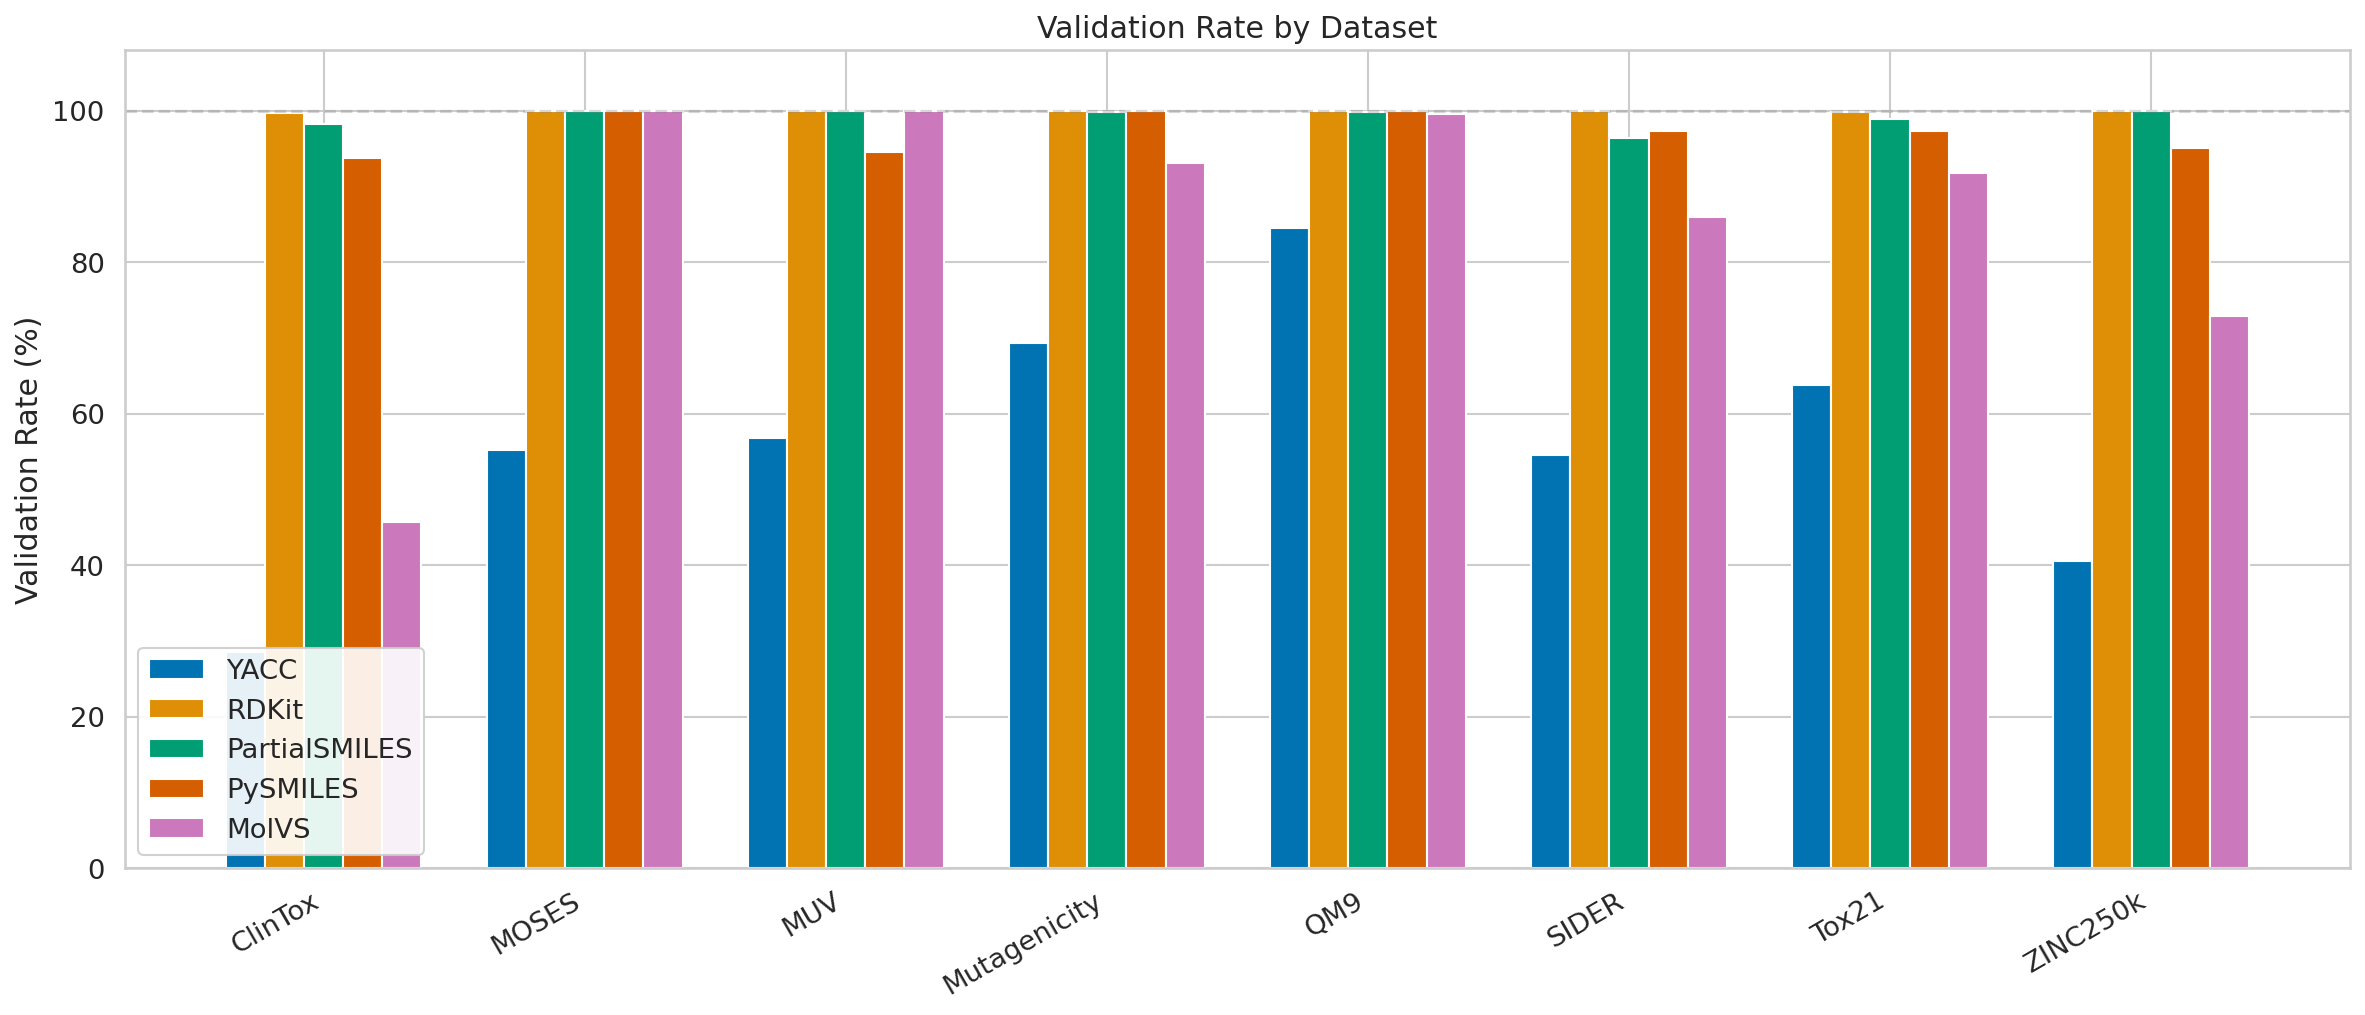

In [6]:
# ── Grouped bar chart: Validation rate by dataset ──
fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(rates))
width = 0.15
colors = sns.color_palette('colorblind', len(validator_names))

for i, v in enumerate(validator_names):
    offset = (i - len(validator_names)/2 + 0.5) * width
    bars = ax.bar(x + offset, rates[v], width, label=v, color=colors[i])

ax.set_ylabel('Validation Rate (%)')
ax.set_title('Validation Rate by Dataset')
ax.set_xticks(x)
ax.set_xticklabels(rates['dataset'], rotation=30, ha='right')
ax.legend(loc='lower left', framealpha=0.9)
ax.set_ylim(0, 108)
ax.axhline(y=100, color='grey', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

In [7]:
# ── Overall pass rates ──
overall = {v: all_df[v].mean() * 100 for v in validator_names}
overall_df = pd.DataFrame([
    {'Validator': k, 'Pass Rate (%)': round(v, 2), 'Molecules Accepted': int(all_df[k].sum()), 'Molecules Rejected': int((~all_df[k]).sum())}
    for k, v in sorted(overall.items(), key=lambda x: -x[1])
])
display(overall_df)

,Validator,Pass Rate (%),Molecules Accepted,Molecules Rejected
0,RDKit,99.98,55021,11
1,PartialSMILES,99.68,54857,175
2,PySMILES,97.50,53658,1374
3,MolVS,91.49,50350,4682
4,YACC,59.77,32892,22140


## 5. Ground Truth Evaluation

### 5a. Hand-Labeled Test Set

In [8]:
def compute_metrics(y_true, y_pred):
    tp = int(((y_true == True)  & (y_pred == True)).sum())
    tn = int(((y_true == False) & (y_pred == False)).sum())
    fp = int(((y_true == False) & (y_pred == True)).sum())
    fn = int(((y_true == True)  & (y_pred == False)).sum())
    n = tp + tn + fp + fn
    acc  = (tp + tn) / n if n else 0
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec  = tp / (tp + fn) if (tp + fn) else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) else 0
    return {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, ci=0.95):
    """Bootstrap 95% confidence interval for a metric."""
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        m = metric_fn(y_true.iloc[idx], y_pred.iloc[idx])
        scores.append(m)
    alpha = (1 - ci) / 2
    return np.percentile(scores, [alpha*100, (1-alpha)*100])

# Load hand-labeled ground truth
gt_df = pd.read_parquet('../tests/data/test_molecules_from_values.parquet').dropna(subset=['smiles'])
gt_df['ground_truth'] = gt_df['is_valid'].astype(bool)

for name, validator in VALIDATORS.items():
    gt_df[name] = gt_df['smiles'].apply(validator)

print(f'Ground truth: {len(gt_df)} molecules ({gt_df["ground_truth"].sum()} valid, {(~gt_df["ground_truth"]).sum()} invalid)')

# Metrics with bootstrap CI
gt_metrics = []
for name in VALIDATORS:
    m = compute_metrics(gt_df['ground_truth'], gt_df[name])
    # Bootstrap CI for F1
    f1_ci = bootstrap_ci(
        gt_df['ground_truth'], gt_df[name],
        lambda yt, yp: compute_metrics(yt, yp)['F1']
    )
    gt_metrics.append({
        'Validator': name, **m,
        'F1 95% CI': f'[{f1_ci[0]:.3f}, {f1_ci[1]:.3f}]',
    })

gt_metrics_df = pd.DataFrame(gt_metrics).sort_values('F1', ascending=False)
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    gt_metrics_df[col] = gt_metrics_df[col].apply(lambda x: f'{x:.2%}')
display(gt_metrics_df)

[17:55:19] Explicit valence for atom # 11 C, 6, is greater than permitted
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9 10 11
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5 7 8 9 11 12 13
[17:55:19] Explicit valence for atom # 15 C, 5, is greater than permitted
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] SMILES Parse Error: unclosed ring for input: 'C1=CC2=CC=C3C=CC=C4C=CC(=C43)C=C2'
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] SMILES Parse Error: unclosed ring for input: 'C1=CC2=C3C(=C1)C=CC=C3C3=C4C(=CC=CC4=CC=C23)C=C2'
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1

[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9 10 11
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5 7 8 9 11 12 13
[17:55:19] Explicit valence for atom # 15 C, 5, is greater than permitted
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] SMILES Parse Error: unclosed ring for input: 'C1=CC2=CC=C3C=CC=C4C=CC(=C43)C=C2'


[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] SMILES Parse Error: unclosed ring for input: 'C1=CC2=C3C(=C1)C=CC=C3C3=C4C(=CC=CC4=CC=C23)C=C2'
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20


[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 7 8 9 10 11
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 7 8 9 10 11
[17:55:19] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 7 8 9 10 11


Ground truth: 126 molecules (94 valid, 32 invalid)


,Validator,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,F1 95% CI
0,YACC,94,32,0,0,100.00%,100.00%,100.00%,100.00%,"[1.000, 1.000]"
1,RDKit,88,11,21,6,78.57%,80.73%,93.62%,86.70%,"[0.816, 0.915]"
4,MolVS,88,11,21,6,78.57%,80.73%,93.62%,86.70%,"[0.816, 0.915]"
2,PartialSMILES,80,11,21,14,72.22%,79.21%,85.11%,82.05%,"[0.759, 0.876]"
3,PySMILES,80,11,21,14,72.22%,79.21%,85.11%,82.05%,"[0.759, 0.876]"


### 5b. Synthetic Invalid SMILES

In [9]:
inv_df = pd.read_parquet('../data/invalid_smiles.parquet')
inv_df['smiles'] = inv_df['smiles'].fillna('')
print(f'Synthetic invalid SMILES: {len(inv_df)} entries across {inv_df["error_category"].nunique()} error categories')
display(inv_df['error_category'].value_counts())

Synthetic invalid SMILES: 52 entries across 18 error categories


error_category
valency              10
unmatched_parens      4
invalid_bracket       4
invalid_syntax        4
invalid_start         4
unmatched_ring        4
bad_aromaticity       4
invalid_bond          3
invalid_element       3
dangling_bond         3
invalid_charge        2
empty                 1
whitespace            1
bad_ring              1
invalid_ring_bond     1
ring_strain           1
disconnected_ring     1
unlikely              1
Name: count, dtype: int64

In [10]:
# All of these should be rejected (ground truth = False)
for name, validator in VALIDATORS.items():
    inv_df[name] = inv_df['smiles'].apply(validator)

# Detection rate = proportion correctly rejected
inv_detection = {}
for name in VALIDATORS:
    rejected = (~inv_df[name]).sum()
    inv_detection[name] = rejected / len(inv_df) * 100

inv_det_df = pd.DataFrame([
    {'Validator': k, 'Detection Rate (%)': round(v, 1), 'Rejected': int((~inv_df[k]).sum()), 'Missed': int(inv_df[k].sum())}
    for k, v in sorted(inv_detection.items(), key=lambda x: -x[1])
])
display(inv_det_df)

[17:55:22] SMILES Parse Error: syntax error while parsing: 
[17:55:22] SMILES Parse Error: check for mistakes around position 1:
[17:55:22] 
[17:55:22] ^
[17:55:22] SMILES Parse Error: Failed parsing SMILES ' ' for input: ' '
[17:55:22] SMILES Parse Error: extra open parentheses while parsing: C(CC
[17:55:22] SMILES Parse Error: check for mistakes around position 2:
[17:55:22] C(CC
[17:55:22] ~^
[17:55:22] SMILES Parse Error: Failed parsing SMILES 'C(CC' for input: 'C(CC'
[17:55:22] SMILES Parse Error: extra close parentheses while parsing: CC)C
[17:55:22] SMILES Parse Error: check for mistakes around position 3:
[17:55:22] CC)C
[17:55:22] ~~^
[17:55:22] SMILES Parse Error: Failed parsing SMILES 'CC)C' for input: 'CC)C'
[17:55:22] SMILES Parse Error: syntax error while parsing: (CC)
[17:55:22] SMILES Parse Error: check for mistakes around position 1:
[17:55:22] (CC)
[17:55:22] ^
[17:55:22] SMILES Parse Error: Failed parsing SMILES '(CC)' for input: '(CC)'
[17:55:22] SMILES Parse Error:

[17:55:23] SMILES Parse Error: syntax error while parsing: 
[17:55:23] SMILES Parse Error: check for mistakes around position 1:
[17:55:23] 
[17:55:23] ^
[17:55:23] SMILES Parse Error: Failed parsing SMILES ' ' for input: ' '
[17:55:23] SMILES Parse Error: extra open parentheses while parsing: C(CC
[17:55:23] SMILES Parse Error: check for mistakes around position 2:
[17:55:23] C(CC
[17:55:23] ~^
[17:55:23] SMILES Parse Error: Failed parsing SMILES 'C(CC' for input: 'C(CC'
[17:55:23] SMILES Parse Error: extra close parentheses while parsing: CC)C
[17:55:23] SMILES Parse Error: check for mistakes around position 3:
[17:55:23] CC)C
[17:55:23] ~~^
[17:55:23] SMILES Parse Error: Failed parsing SMILES 'CC)C' for input: 'CC)C'
[17:55:23] SMILES Parse Error: syntax error while parsing: (CC)
[17:55:23] SMILES Parse Error: check for mistakes around position 1:
[17:55:23] (CC)
[17:55:23] ^
[17:55:23] SMILES Parse Error: Failed parsing SMILES '(CC)' for input: '(CC)'
[17:55:23] SMILES Parse Error:

[17:55:23] SMILES Parse Error: unclosed ring for input: 'C1CC'


[17:55:23] SMILES Parse Error: unclosed ring for input: 'C1CCC2CC'
[17:55:23] SMILES Parse Error: unclosed ring for input: 'C12CC'
[17:55:23] SMILES Parse Error: unclosed ring for input: 'C%10CCC'
[17:55:23] SMILES Parse Error: syntax error while parsing: =CC
[17:55:23] SMILES Parse Error: check for mistakes around position 1:
[17:55:23] =CC
[17:55:23] ^
[17:55:23] SMILES Parse Error: Failed parsing SMILES '=CC' for input: '=CC'
[17:55:23] SMILES Parse Error: syntax error while parsing: #CC
[17:55:23] SMILES Parse Error: check for mistakes around position 1:
[17:55:23] #CC
[17:55:23] ^
[17:55:23] SMILES Parse Error: Failed parsing SMILES '#CC' for input: '#CC'


[17:55:23] SMILES Parse Error: syntax error while parsing: .C..C
[17:55:23] SMILES Parse Error: check for mistakes around position 1:
[17:55:23] .C..C
[17:55:23] ^
[17:55:23] SMILES Parse Error: Failed parsing SMILES '.C..C' for input: '.C..C'
[17:55:23] SMILES Parse Error: syntax error while parsing: C=
[17:55:23] SMILES Parse Error: check for mistakes around position 2:
[17:55:23] C=
[17:55:23] ~^
[17:55:23] SMILES Parse Error: Failed parsing SMILES 'C=' for input: 'C='


...

[17:55:24] Can't kekulize mol.  Unkekulized atoms: 0 1 2


[17:55:24] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[17:55:24] Explicit valence for atom # 1 C, 5, is greater than permitted
[17:55:24] Explicit valence for atom # 0 S, 9, is greater than permitted
[17:55:24] Explicit valence for atom # 0 P, 9, is greater than permitted


[17:55:24] SMILES Parse Error: syntax error while parsing: C.C.C.C.C.
[17:55:24] SMILES Parse Error: check for mistakes around position 10:
[17:55:24] C.C.C.C.C.
[17:55:24] ~~~~~~~~~^
[17:55:24] SMILES Parse Error: Failed parsing SMILES 'C.C.C.C.C.' for input: 'C.C.C.C.C.'
[17:55:24] SMILES Parse Error: syntax error while parsing: (C)
[17:55:24] SMILES Parse Error: check for mistakes around position 1:
[17:55:24] (C)
[17:55:24] ^
[17:55:24] SMILES Parse Error: Failed parsing SMILES '(C)' for input: '(C)'
[17:55:24] SMILES Parse Error: syntax error while parsing: C()C
[17:55:24] SMILES Parse Error: check for mistakes around position 3:
[17:55:24] C()C
[17:55:24] ~~^
[17:55:24] SMILES Parse Error: Failed parsing SMILES 'C()C' for input: 'C()C'
[17:55:24] SMILES Parse Error: syntax error while parsing: C()(C)C
[17:55:24] SMILES Parse Error: check for mistakes around position 3:
[17:55:24] C()(C)C
[17:55:24] ~~^
[17:55:24] SMILES Parse Error: Failed parsing SMILES 'C()(C)C' for input: 'C()

[17:55:24] Explicit valence for atom # 9 C, 5, is greater than permitted


,Validator,Detection Rate (%),Rejected,Missed
0,MolVS,90.4,47,5
1,PartialSMILES,88.5,46,6
2,YACC,82.7,43,9
3,RDKit,80.8,42,10
4,PySMILES,55.8,29,23


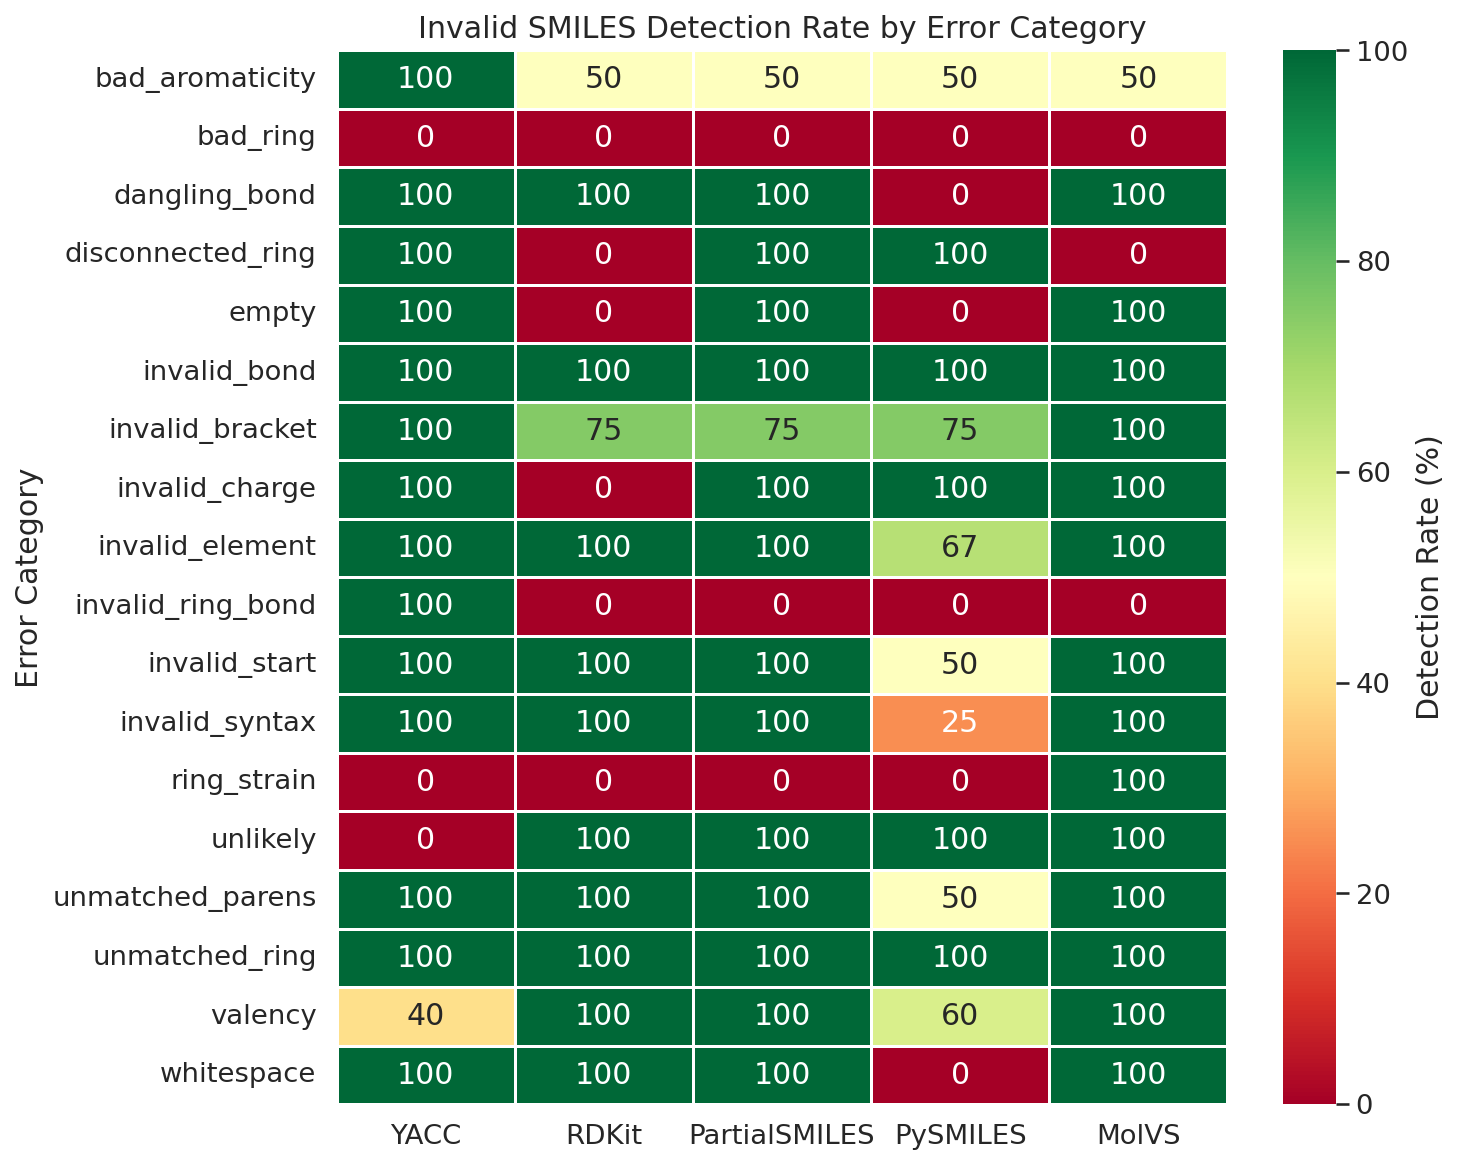

In [11]:
# ── Per-category detection heatmap ──
cat_results = inv_df.groupby('error_category')[validator_names].apply(
    lambda g: (~g).mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cat_results, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Detection Rate (%)'})
ax.set_title('Invalid SMILES Detection Rate by Error Category')
ax.set_ylabel('Error Category')
plt.tight_layout()

plt.show()

In [12]:
# Show which invalid SMILES each validator incorrectly accepts
print('=== False Positives on Synthetic Invalid Set ===')
for name in VALIDATORS:
    fps = inv_df[inv_df[name] == True]
    if len(fps) > 0:
        print(f'\n{name} incorrectly accepts {len(fps)} invalid SMILES:')
        for _, row in fps.iterrows():
            print(f'  [{row["error_category"]}] {repr(row["smiles"])}: {row["description"]}')
    else:
        print(f'\n{name}: Correctly rejects all invalid SMILES')

=== False Positives on Synthetic Invalid Set ===

YACC incorrectly accepts 9 invalid SMILES:
  [valency] 'C(C)(C)(C)(C)(C)C': Hexavalent carbon
  [valency] 'N(C)(C)(C)(C)C': Pentavalent nitrogen with 5 single bonds
  [valency] 'O(C)(C)(C)C': Tetravalent oxygen with 4 single bonds
  [bad_ring] 'C1=CC=CC=CC=CC=C1': 10-membered ring with alternating bonds
  [valency] 'CC(C)(C)(C)CC': Carbon with 5 bonds total
  [valency] 'S(=O)(=O)(=O)(=O)C': Sulfur with too many double bonds
  [valency] 'P(=O)(=O)(=O)(=O)C': Phosphorus with too many double bonds
  [ring_strain] 'C1CC1=O': Cyclopropanone - strained ring
  [unlikely] 'CC(=O)C(=O)C(=O)C(=O)C(=O)=O': Chain of carbonyls (syntactically ok but chemically unlikely)

RDKit incorrectly accepts 10 invalid SMILES:
  [empty] '': Empty string
  [bad_aromaticity] 'c1ccc1': 4-membered aromatic ring
  [bad_aromaticity] 'c1ccc2cc1cc2': Invalid fused aromatic system
  [bad_ring] 'C1=CC=CC=CC=CC=C1': 10-membered ring with alternating bonds
  [invalid_ring_b

## 6. Inter-Validator Agreement

### 6a. Cohen's Kappa (Pairwise)

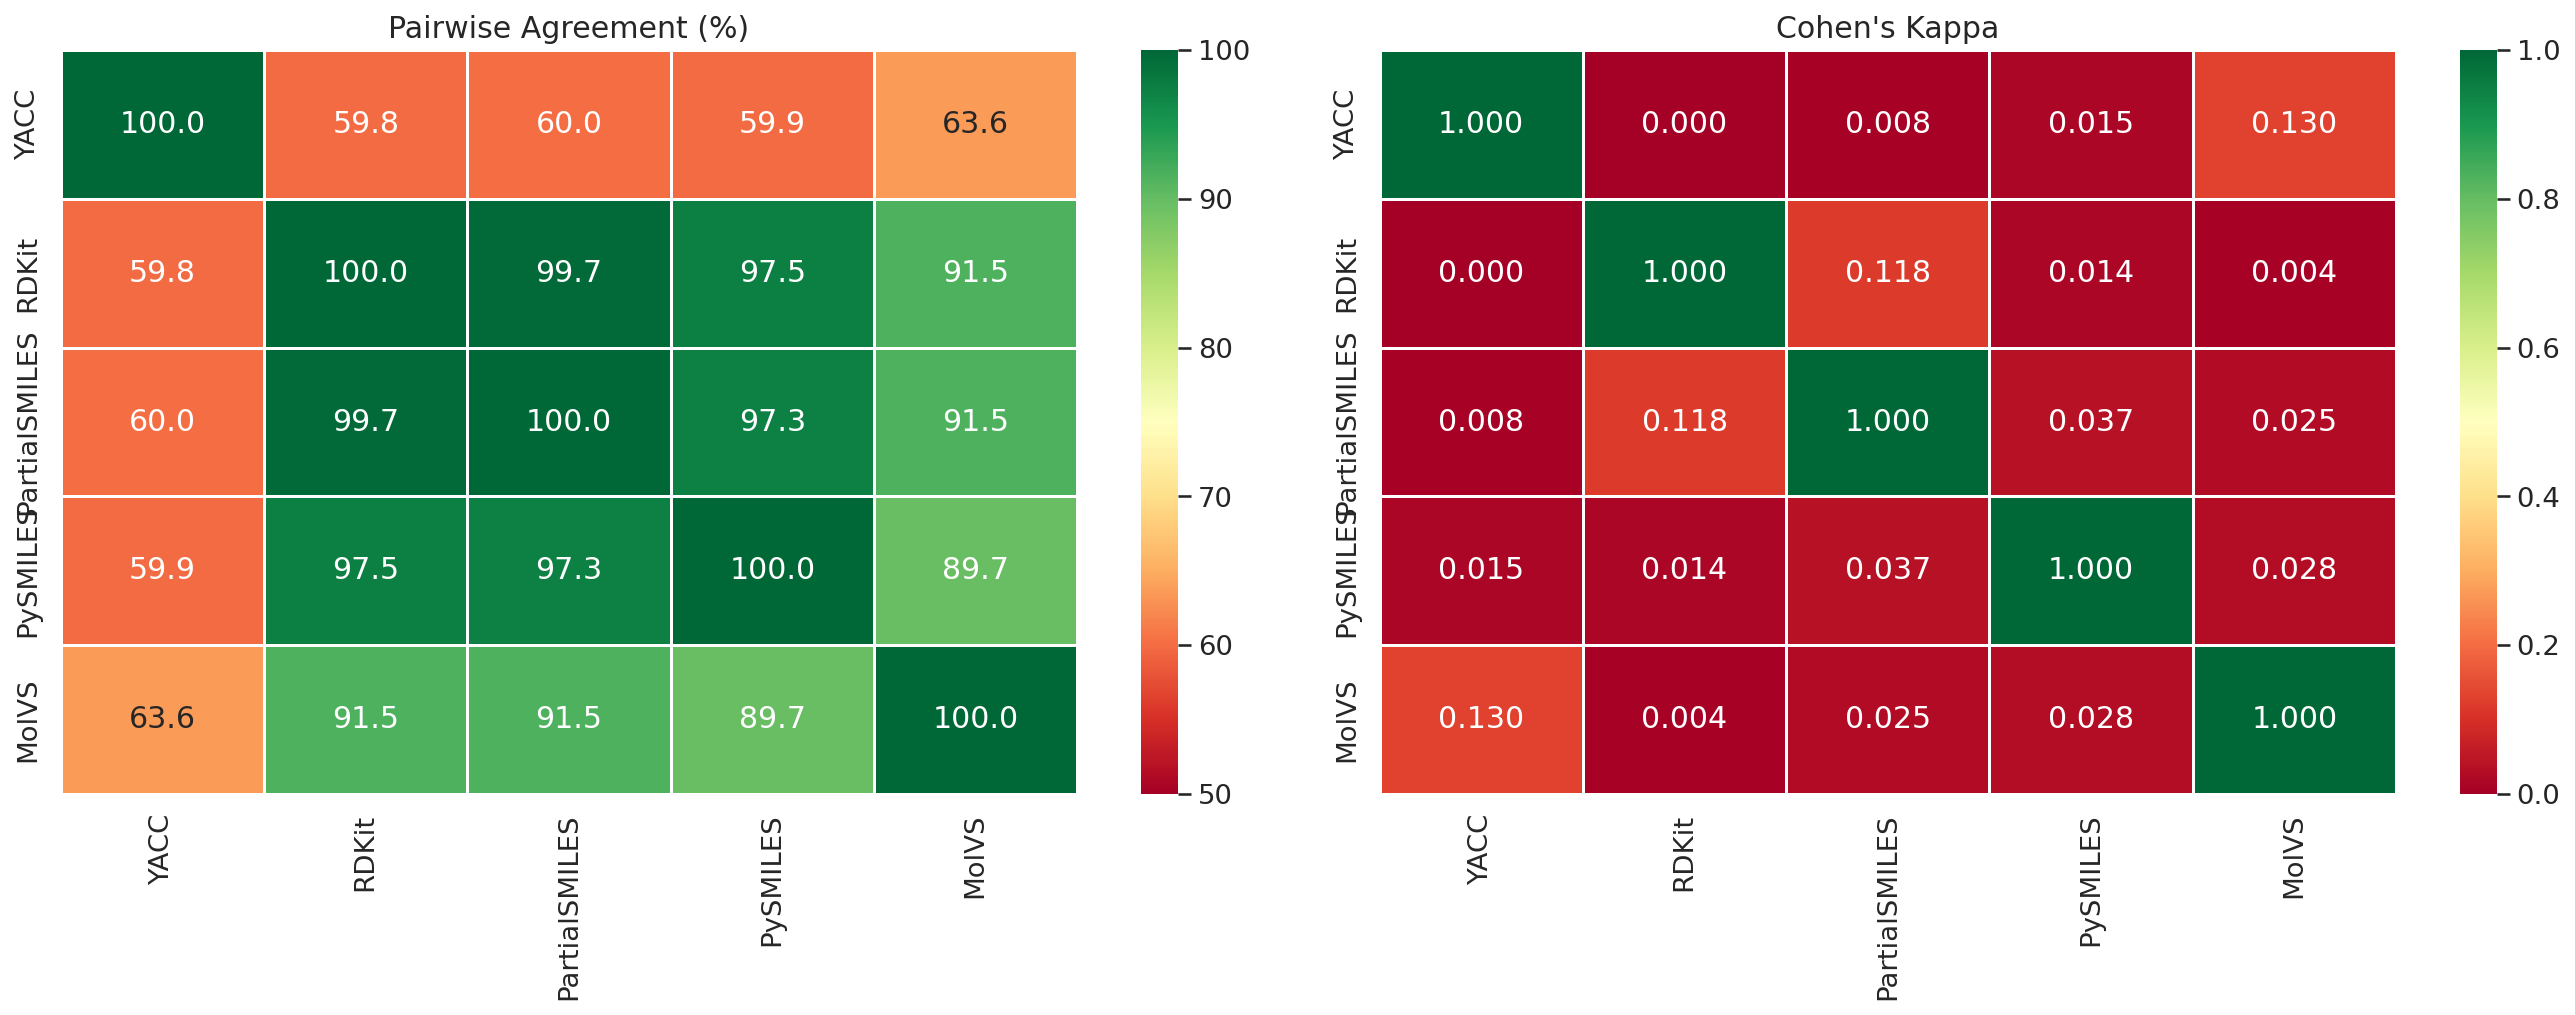

In [13]:
def cohens_kappa(y1, y2):
    """Compute Cohen's kappa between two binary arrays."""
    n = len(y1)
    po = (y1 == y2).mean()  # observed agreement
    p1 = y1.mean()
    p2 = y2.mean()
    pe = p1*p2 + (1-p1)*(1-p2)  # expected agreement by chance
    if pe == 1:
        return 1.0
    return (po - pe) / (1 - pe)

# Pairwise Cohen's kappa
kappa_matrix = pd.DataFrame(index=validator_names, columns=validator_names, dtype=float)
agreement_matrix = pd.DataFrame(index=validator_names, columns=validator_names, dtype=float)

for v1 in validator_names:
    for v2 in validator_names:
        kappa_matrix.loc[v1, v2] = cohens_kappa(all_df[v1], all_df[v2])
        agreement_matrix.loc[v1, v2] = (all_df[v1] == all_df[v2]).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(agreement_matrix.astype(float), annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0], vmin=50, vmax=100, linewidths=0.5)
axes[0].set_title('Pairwise Agreement (%)')

sns.heatmap(kappa_matrix.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[1], vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title("Cohen's Kappa")

plt.tight_layout()

plt.show()

### 6b. Consensus Analysis

In [14]:
# How many validators agree each molecule is valid?
all_df['n_valid'] = all_df[validator_names].sum(axis=1)

consensus = all_df['n_valid'].value_counts().sort_index()
consensus_df = pd.DataFrame({
    'Validators Agreeing Valid': consensus.index,
    'Count': consensus.values,
    'Percentage': (consensus.values / len(all_df) * 100).round(2)
})
display(consensus_df)

# Unanimous agreement
all_valid = (all_df['n_valid'] == len(VALIDATORS)).sum()
all_invalid = (all_df['n_valid'] == 0).sum()
print(f'\nUnanimous VALID:   {all_valid:,} ({all_valid/len(all_df)*100:.1f}%)')
print(f'Unanimous INVALID: {all_invalid:,} ({all_invalid/len(all_df)*100:.1f}%)')
print(f'Disagreement:      {len(all_df) - all_valid - all_invalid:,} ({(len(all_df) - all_valid - all_invalid)/len(all_df)*100:.1f}%)')

,Validators Agreeing Valid,Count,Percentage
0,0,6,0.01
1,1,12,0.02
2,2,220,0.40
3,3,3809,6.92
4,4,20026,36.39
5,5,30959,56.26



Unanimous VALID:   30,959 (56.3%)
Unanimous INVALID: 6 (0.0%)
Disagreement:      24,067 (43.7%)


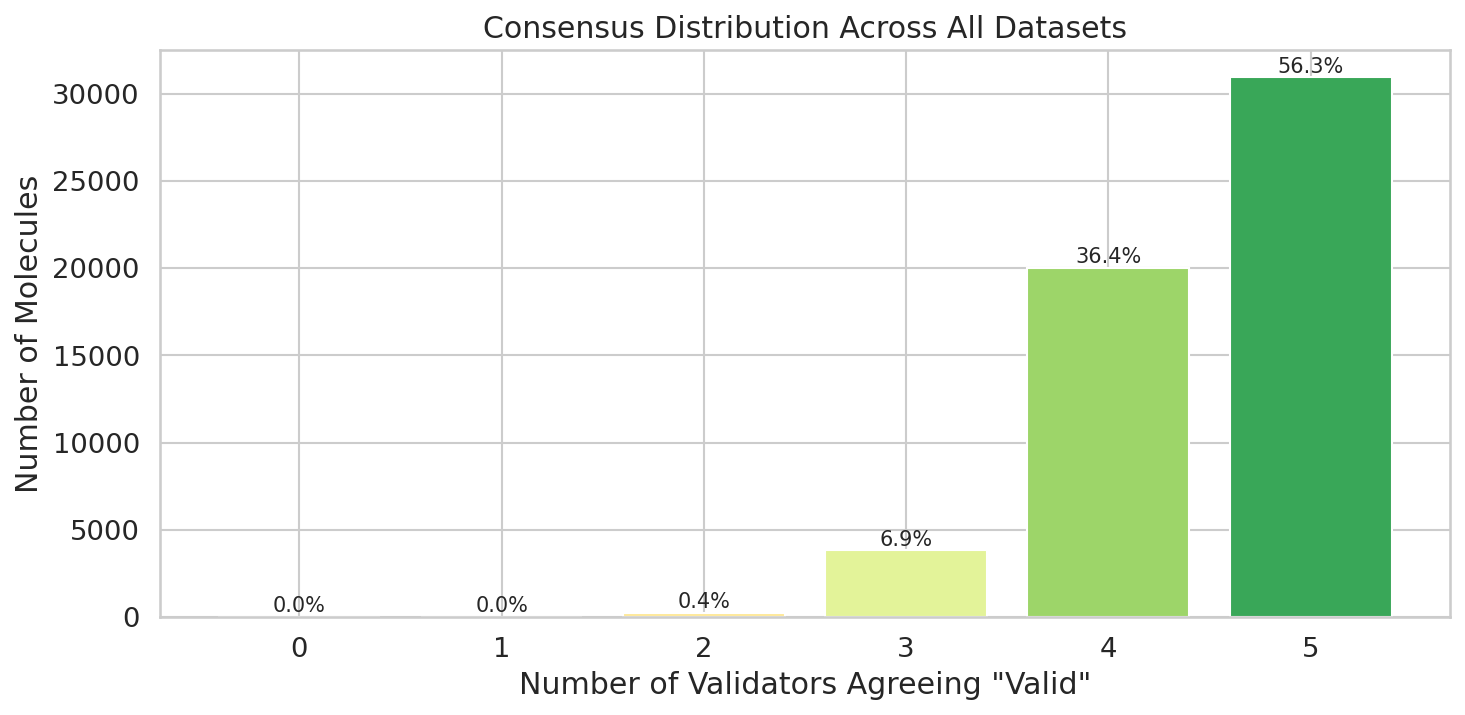

In [15]:
# Consensus bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors_cons = sns.color_palette('RdYlGn', len(consensus))
bars = ax.bar(consensus_df['Validators Agreeing Valid'].astype(str), consensus_df['Count'], color=colors_cons)
ax.set_xlabel('Number of Validators Agreeing "Valid"')
ax.set_ylabel('Number of Molecules')
ax.set_title('Consensus Distribution Across All Datasets')
for bar, pct in zip(bars, consensus_df['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(all_df)*0.005,
            f'{pct:.1f}%', ha='center', fontsize=10)
plt.tight_layout()

plt.show()

## 7. Disagreement Analysis

### 7a. YACC vs RDKit Disagreements

In [16]:
# YACC accepts, RDKit rejects (and vice versa)
yacc_only = all_df[(all_df['YACC'] == True) & (all_df['RDKit'] == False)]
rdkit_only = all_df[(all_df['YACC'] == False) & (all_df['RDKit'] == True)]
both_valid = all_df[(all_df['YACC'] == True) & (all_df['RDKit'] == True)]
both_invalid = all_df[(all_df['YACC'] == False) & (all_df['RDKit'] == False)]

print('YACC vs RDKit comparison:')
print(f'  Both valid:   {len(both_valid):>7,}')
print(f'  Both invalid: {len(both_invalid):>7,}')
print(f'  YACC only:    {len(yacc_only):>7,} (YACC accepts, RDKit rejects)')
print(f'  RDKit only:   {len(rdkit_only):>7,} (RDKit accepts, YACC rejects)')

YACC vs RDKit comparison:
  Both valid:    32,888
  Both invalid:       7
  YACC only:          4 (YACC accepts, RDKit rejects)
  RDKit only:    22,133 (RDKit accepts, YACC rejects)


,Reason,Count,%
0,Valency Check,358,71.6
1,Trailing C Check,101,20.2
2,Aromaticity (Hückel),33,6.6
3,Other,8,1.6


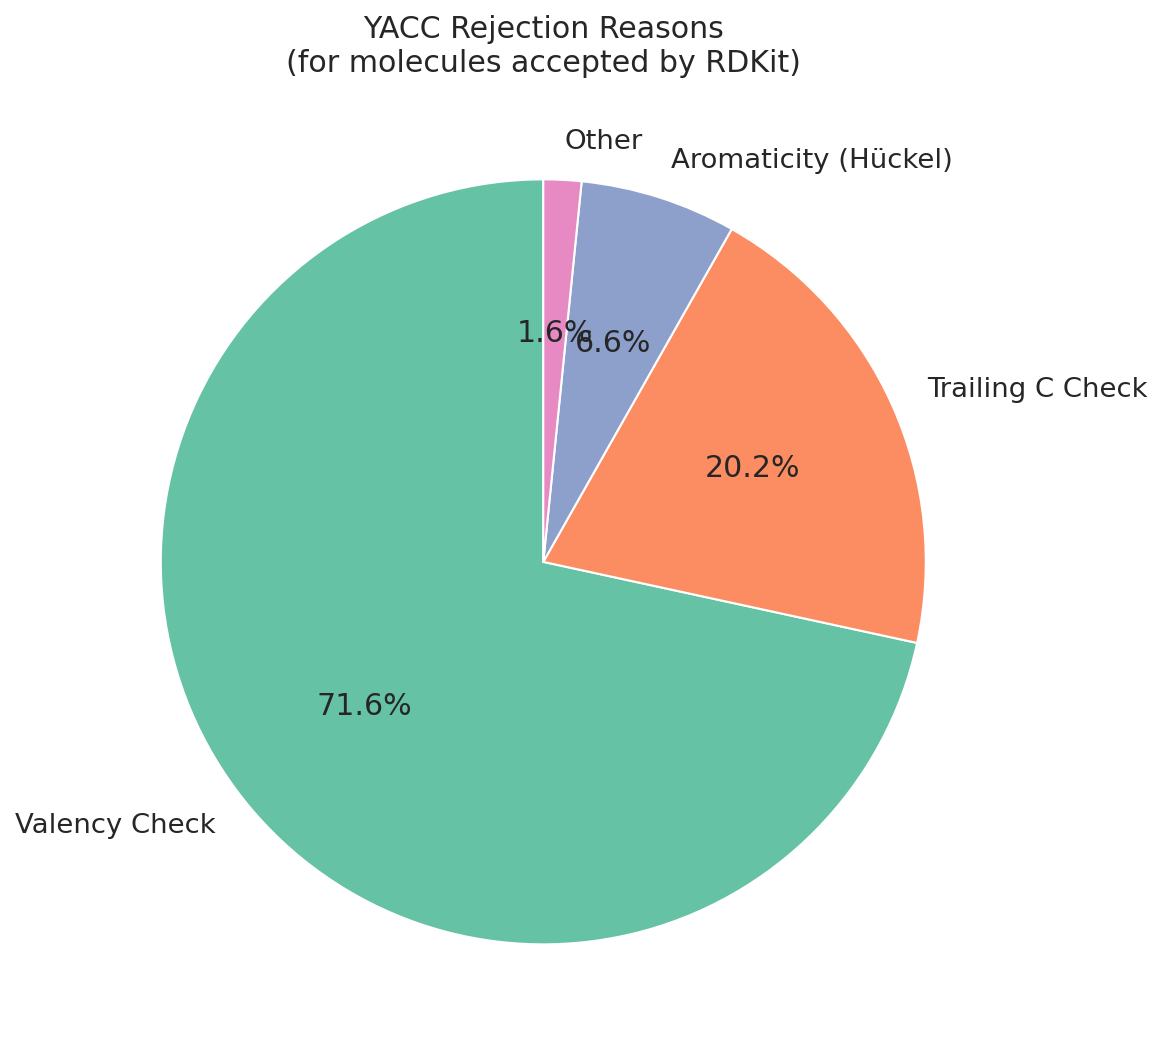

In [17]:
# Categorize WHY YACC rejects molecules that RDKit accepts
if len(rdkit_only) > 0:
    sample_rdkit_only = rdkit_only.head(500)
    rejection_reasons = []
    for smi in sample_rdkit_only['smiles']:
        _, err = validate_smiles(smi)
        err_str = str(err) if err else 'unknown'
        if 'validate_smiles' in err_str:
            rejection_reasons.append('Trailing C Check')
        elif 'validate_rings_and_valency' in err_str:
            rejection_reasons.append('Valency Check')
        elif 'validate_aromaticity' in err_str or 'huckel' in err_str.lower() or 'Hückel' in err_str:
            rejection_reasons.append('Aromaticity (Hückel)')
        elif 'Parser' in err_str or 'parse' in err_str.lower() or 'Syntax' in err_str:
            rejection_reasons.append('Syntax / Parsing')
        else:
            rejection_reasons.append('Other')

    reason_counts = pd.Series(rejection_reasons).value_counts()
    reason_df = pd.DataFrame({
        'Reason': reason_counts.index,
        'Count': reason_counts.values,
        '%': (reason_counts.values / len(reason_counts) * 100).round(1)
    })
    reason_df['%'] = (reason_counts.values / reason_counts.sum() * 100).round(1)
    display(reason_df)

    # Pie chart
    fig, ax = plt.subplots(figsize=(8, 8))
    colors_pie = sns.color_palette('Set2', len(reason_counts))
    ax.pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%',
           colors=colors_pie, startangle=90)
    ax.set_title('YACC Rejection Reasons\n(for molecules accepted by RDKit)')
    plt.tight_layout()
    
    plt.show()

In [18]:
# Sample of specific disagreements for manual inspection
if len(rdkit_only) > 0:
    print('Sample SMILES accepted by RDKit but rejected by YACC:')
    print('=' * 80)
    for _, row in rdkit_only.head(15).iterrows():
        _, err = validate_smiles(row['smiles'])
        print(f"  Dataset: {row['dataset']}")
        print(f"  SMILES:  {row['smiles'][:80]}")
        print(f"  Error:   {err}")
        print()

Sample SMILES accepted by RDKit but rejected by YACC:
  Dataset: ClinTox
  SMILES:  *C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC
  Error:   Illegal character '*' at index 0

  Dataset: ClinTox
  SMILES:  [C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)[O-])O)O
  Error:   validate_rings_and_valency: Invalid valency for atom C in acyclic part (parameter: BracketAtom(symbol='C', chiral='clockwise', hcount=1))

  Dataset: ClinTox
  SMILES:  [H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])N)cc2)/C=C1)\N
  Error:   validate_rings_and_valency: Invalid valency for atom H in acyclic part (parameter: BracketAtom(symbol='H'))

  Dataset: ClinTox
  SMILES:  [H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(=[NH+]/[H])/N
  Error:   validate_rings_and_valency: Invalid valency for atom H in acyclic part (parameter: BracketAtom(symbol='H'))

  Dataset: ClinTox
  SMILES:  [N+](=O)([O-])[O-]
  Error:   validate_rings_and_valency: Invalid valency for atom N in acyclic part (parameter: BracketAtom(symbol='N', charge=1

### 7b. Pairwise Disagreement Counts

In [19]:
# For each pair: how many molecules does one accept that the other rejects?
disagree_data = []
for i, v1 in enumerate(validator_names):
    for j, v2 in enumerate(validator_names):
        if i < j:
            v1_only = ((all_df[v1] == True) & (all_df[v2] == False)).sum()
            v2_only = ((all_df[v1] == False) & (all_df[v2] == True)).sum()
            disagree_data.append({
                'Pair': f'{v1} vs {v2}',
                f'{v1} only': int(v1_only),
                f'{v2} only': int(v2_only),
                'Total Disagreements': int(v1_only + v2_only),
            })

disagree_df = pd.DataFrame(disagree_data).sort_values('Total Disagreements', ascending=False)
display(disagree_df.head(10))

,Pair,YACC only,RDKit only,Total Disagreements,PartialSMILES only,PySMILES only,MolVS only
0,YACC vs RDKit,4.0,22133.0,22137,NaN,NaN,NaN
2,YACC vs PySMILES,658.0,NaN,22082,NaN,21424.0,NaN
1,YACC vs PartialSMILES,20.0,NaN,22005,21985.0,NaN,NaN
3,YACC vs MolVS,1299.0,NaN,20056,NaN,NaN,18757.0
9,PySMILES vs MolVS,NaN,NaN,5658,NaN,4483.0,1175.0
8,PartialSMILES vs MolVS,NaN,NaN,4705,4606.0,NaN,99.0
6,RDKit vs MolVS,NaN,4671.0,4671,NaN,NaN,0.0
7,PartialSMILES vs PySMILES,NaN,NaN,1483,1341.0,142.0,NaN
5,RDKit vs PySMILES,NaN,1364.0,1365,NaN,1.0,NaN
4,RDKit vs PartialSMILES,NaN,164.0,164,0.0,NaN,NaN


## 7c. Comprehensive YACC Error Analysis

This section performs a deep analysis of every molecule that YACC rejects. We decompose rejections by:
1. **Error stage** — Where in the pipeline the rejection occurs (regex pre-check, syntax parsing, valency, aromaticity)
2. **Fine-grained error sub-type** — What specifically triggers the rejection
3. **Dataset distribution** — Which datasets are most affected
4. **Comparison with syntax-only mode** — How many rejections are from chemistry checks vs parsing failures

In [20]:
import re as _re

def classify_yacc_error(smiles):
    """Classify a YACC rejection into (stage, category, subcategory, detail)."""
    status, err = validate_smiles(smiles)
    if status:
        return ('accepted', 'accepted', 'accepted', None)
    
    err_str = str(err) if err else 'unknown'
    
    # Stage 1: Trailing C regex pre-check
    if 'validate_smiles' in err_str and 'aromatic and aliphatic' in err_str:
        if _re.search(r'c\d.*C$', smiles):
            return ('regex_precheck', 'trailing_C', 'aromatic_ring+C', smiles[-20:])
        elif _re.search(r'C\d.*C$', smiles):
            return ('regex_precheck', 'trailing_C', 'aliphatic_ring+C', smiles[-20:])
        else:
            return ('regex_precheck', 'trailing_C', 'other_ring+C', smiles[-20:])
    
    # Stage 2a: Illegal character (lexer error - before parsing)
    if 'Illegal character' in err_str:
        char_match = _re.search(r"'(.+?)'", err_str)
        bad_char = char_match.group(1) if char_match else '?'
        if bad_char == '\\n' or 'newline' in bad_char.lower() or bad_char == '\n':
            return ('data_quality', 'illegal_char', 'newline_in_smiles', err_str[:80])
        elif bad_char == '*':
            return ('syntax', 'illegal_char', 'wildcard_atom', err_str[:80])
        elif bad_char == '~':
            return ('syntax', 'illegal_char', 'any_bond', err_str[:80])
        else:
            return ('syntax', 'illegal_char', f'char={bad_char}', err_str[:80])
    
    # Stage 2b: Syntax parsing errors
    if 'Parser' in err_str or 'Syntax' in err_str or 'parse' in err_str.lower():
        if 'unclosed ring' in err_str.lower():
            return ('syntax', 'unclosed_ring', 'ring_mismatch', err_str[:80])
        elif 'parenthes' in err_str.lower():
            return ('syntax', 'parenthesis', 'bracket_mismatch', err_str[:80])
        else:
            return ('syntax', 'parse_error', 'other', err_str[:80])
    
    # Stage 2c: Chain rule errors (from yacc grammar)
    if 'chain' in err_str and 'Invalid chain rule' in err_str:
        if 'dot_proxy' in err_str:
            return ('syntax', 'chain_error', 'dot_proxy', err_str[:80])
        else:
            return ('syntax', 'chain_error', 'other', err_str[:80])
    
    # Stage 3: Valency check
    if 'validate_rings_and_valency' in err_str:
        atom_match = _re.search(r"atom (\w+)", err_str)
        atom_sym = atom_match.group(1) if atom_match else '?'
        bracket_match = _re.search(r"BracketAtom\(([^)]+)\)", err_str)
        bracket_detail = bracket_match.group(1) if bracket_match else ''
        
        has_charge = 'charge=' in bracket_detail
        has_hcount = 'hcount=' in bracket_detail
        
        if has_charge:
            charge_match = _re.search(r'charge=(-?\d+)', bracket_detail)
            charge = int(charge_match.group(1)) if charge_match else 0
            if charge < 0:
                subcat = f'{atom_sym}_negative_charge'
            else:
                subcat = f'{atom_sym}_positive_charge'
        elif atom_sym == 'H':
            subcat = 'bracket_hydrogen'
        elif has_hcount and not has_charge:
            subcat = f'{atom_sym}_explicit_H'
        else:
            subcat = f'{atom_sym}_no_charge_no_H'
        
        return ('chemistry_valency', 'valency', subcat, bracket_detail[:80])
    
    # Stage 4: Aromaticity
    if 'validate_aromaticity' in err_str or 'huckel' in err_str.lower() or 'Hückel' in err_str:
        aromatic_atoms = _re.findall(r'[a-z]', smiles)
        n_aromatic = len(aromatic_atoms)
        return ('chemistry_aromaticity', 'huckel', f'{n_aromatic}_aromatic_atoms', err_str[:80])
    
    return ('other', 'other', 'unclassified', err_str[:120])

# Run classification on ALL rejected molecules
print('Classifying all YACC rejections...', flush=True)
yacc_rejected = all_df[all_df['YACC'] == False].copy()
print(f'Total rejections: {len(yacc_rejected):,}')

classifications = yacc_rejected['smiles'].apply(classify_yacc_error)
yacc_rejected['stage'] = classifications.apply(lambda x: x[0])
yacc_rejected['category'] = classifications.apply(lambda x: x[1])
yacc_rejected['subcategory'] = classifications.apply(lambda x: x[2])
yacc_rejected['detail'] = classifications.apply(lambda x: x[3])
print('Done.')

Classifying all YACC rejections...


Total rejections: 22,140


Done.


### 7c.1. Rejection Breakdown by Pipeline Stage

,Pipeline Stage,Rejections,% of All Rejections,% of All Molecules
0,chemistry_aromaticity,11102,50.14,20.17
1,chemistry_valency,5188,23.43,9.43
2,regex_precheck,5154,23.28,9.37
3,syntax,695,3.14,1.26
4,other,1,0.00,0.00


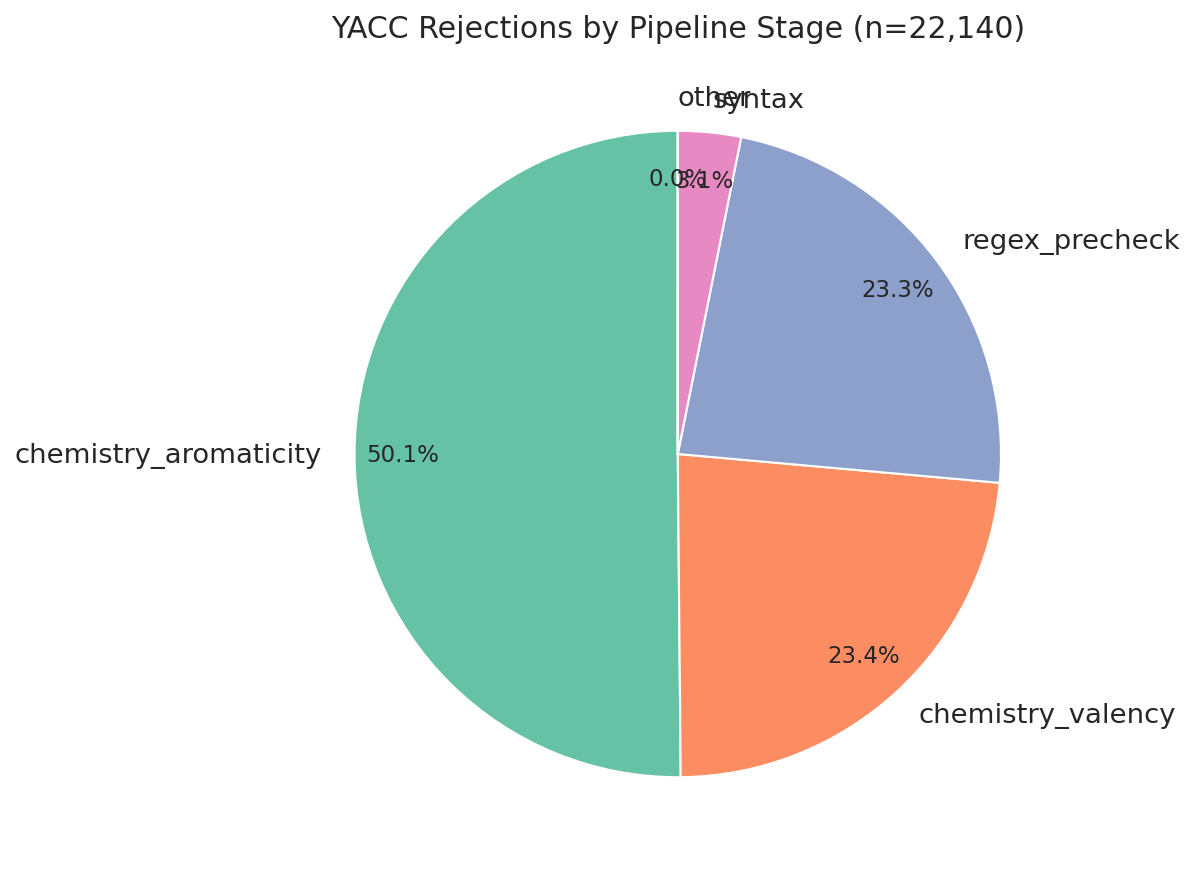

In [21]:
stage_counts = yacc_rejected['stage'].value_counts()
stage_df = pd.DataFrame({
    'Pipeline Stage': stage_counts.index,
    'Rejections': stage_counts.values,
    '% of All Rejections': (stage_counts.values / len(yacc_rejected) * 100).round(2),
    '% of All Molecules': (stage_counts.values / len(all_df) * 100).round(2),
})
display(stage_df)

fig, ax = plt.subplots(figsize=(8, 8))
colors_stage = sns.color_palette('Set2', len(stage_counts))
wedges, texts, autotexts = ax.pie(
    stage_counts.values, labels=stage_counts.index, autopct='%1.1f%%',
    colors=colors_stage, startangle=90, pctdistance=0.85
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title(f'YACC Rejections by Pipeline Stage (n={len(yacc_rejected):,})')
plt.tight_layout()
plt.show()

### 7c.2. Fine-Grained Error Categories

In [22]:
cat_counts = yacc_rejected.groupby(['stage', 'category', 'subcategory']).size().reset_index(name='count')
cat_counts['%'] = (cat_counts['count'] / len(yacc_rejected) * 100).round(2)
cat_counts = cat_counts.sort_values('count', ascending=False)
display(cat_counts.head(25))

,stage,category,subcategory,count,%
109,regex_precheck,trailing_C,aromatic_ring+C,3512,15.86
3,chemistry_aromaticity,huckel,12_aromatic_atoms,2524,11.40
51,chemistry_valency,valency,C_explicit_H,2323,10.49
2,chemistry_aromaticity,huckel,11_aromatic_atoms,1890,8.54
76,chemistry_valency,valency,N_positive_charge,1712,7.73
108,regex_precheck,trailing_C,aliphatic_ring+C,1534,6.93
30,chemistry_aromaticity,huckel,6_aromatic_atoms,1320,5.96
8,chemistry_aromaticity,huckel,17_aromatic_atoms,843,3.81
77,chemistry_valency,valency,O_negative_charge,757,3.42
7,chemistry_aromaticity,huckel,16_aromatic_atoms,695,3.14


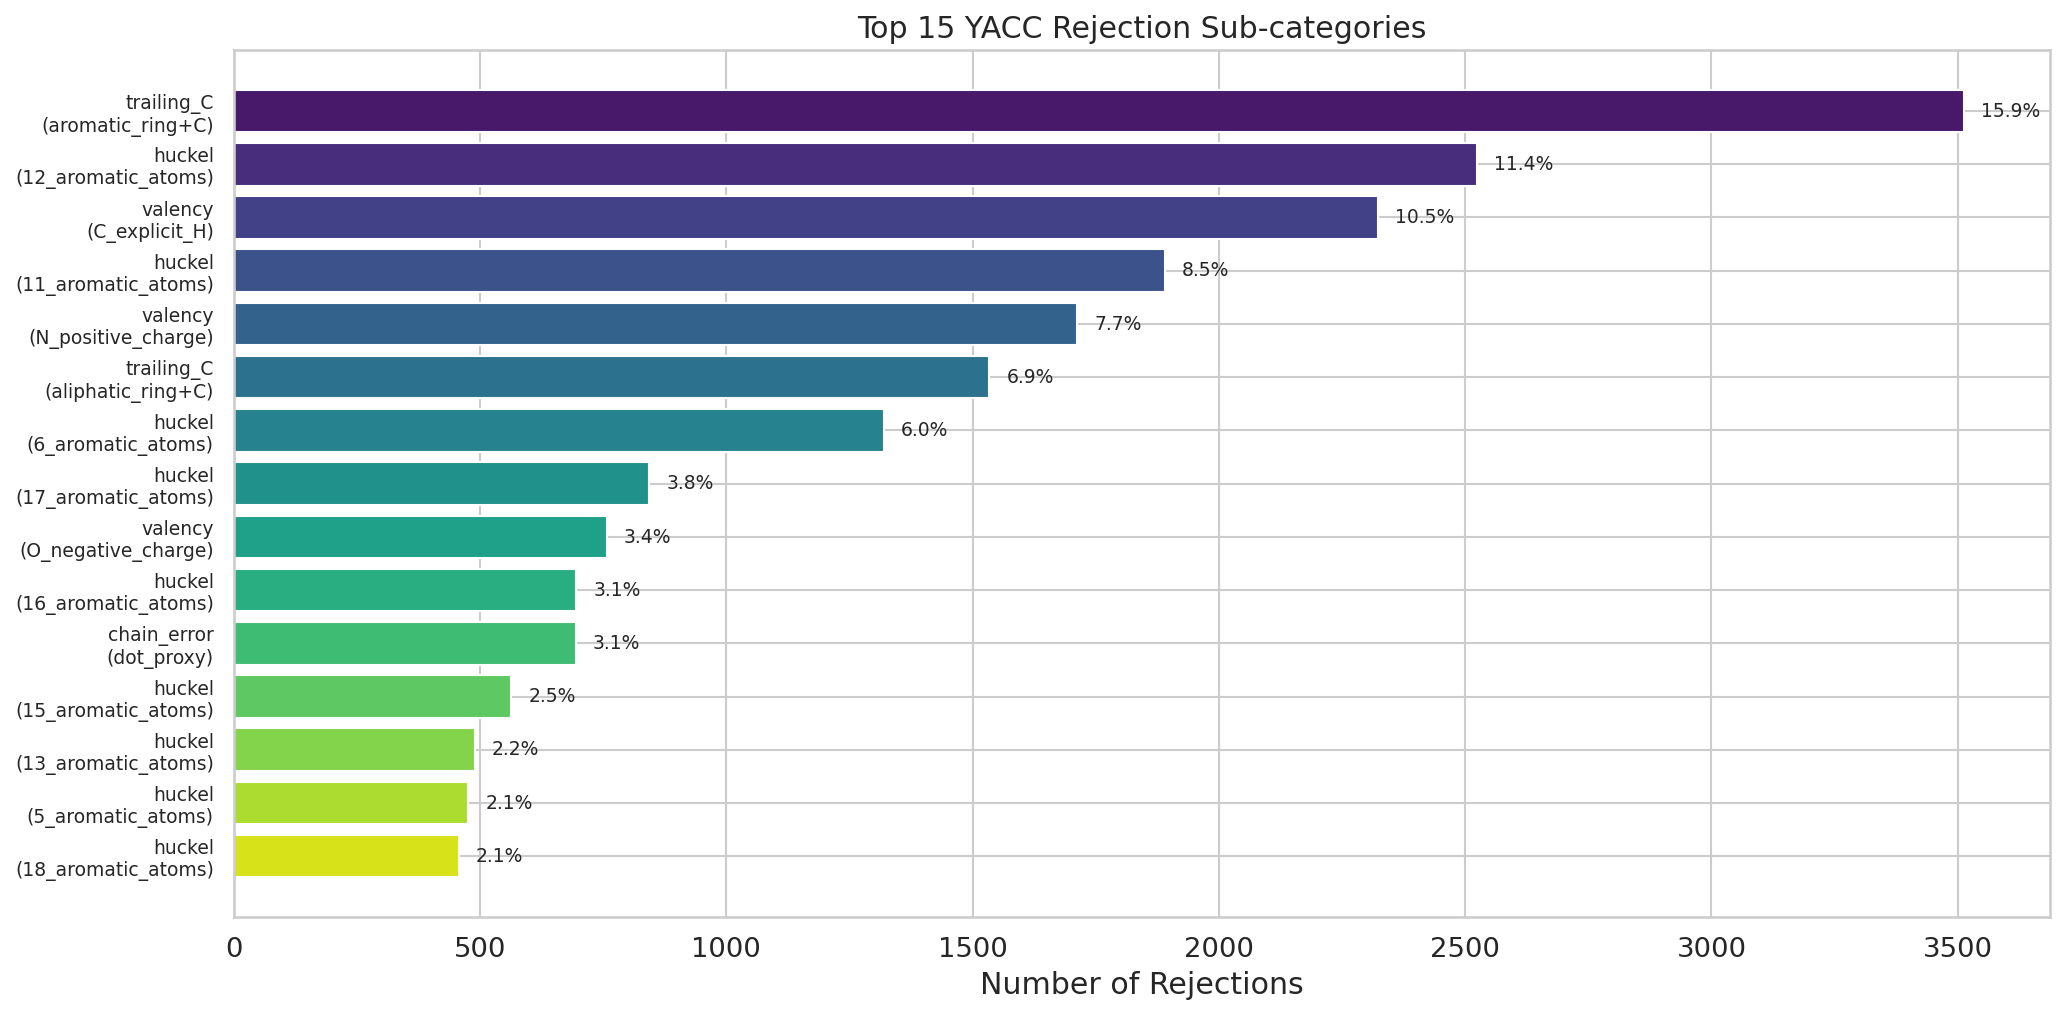

In [23]:
top_subcats = cat_counts.head(15)

fig, ax = plt.subplots(figsize=(14, 7))
labels = [f"{row['category']}\n({row['subcategory']})" for _, row in top_subcats.iterrows()]
colors_cat = sns.color_palette('viridis', len(top_subcats))
bars = ax.barh(range(len(top_subcats)), top_subcats['count'], color=colors_cat)
ax.set_yticks(range(len(top_subcats)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Number of Rejections')
ax.set_title('Top 15 YACC Rejection Sub-categories')
ax.invert_yaxis()

for bar, pct in zip(bars, top_subcats['%']):
    ax.text(bar.get_width() + max(top_subcats['count'])*0.01, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 7c.3. Valency Errors — Deep Dive

The valency check (`compute_valency`) uses the octet rule: a bracket atom's valence shell must have exactly 8 electrons (or 2 for H/He). This fails for:
- **Charged atoms** like `[O-]`, `[N+]`, `[NH4+]` — charge changes electron count
- **Bracket hydrogen** `[H]` when bonded — the check expects 2 electrons in valence
- **Atoms with explicit H** — electron adjustment may over/undershoot the octet

,Atom Pattern,Count,%
0,C_explicit_H,2323,44.8
1,N_positive_charge,1712,33.0
2,O_negative_charge,757,14.6
3,C_no_charge_no_H,86,1.7
4,N_negative_charge,59,1.1
...,...,...,...
68,PT_no_charge_no_H,1,0.0
69,SB_no_charge_no_H,1,0.0
70,BI_no_charge_no_H,1,0.0
71,NI_positive_charge,1,0.0


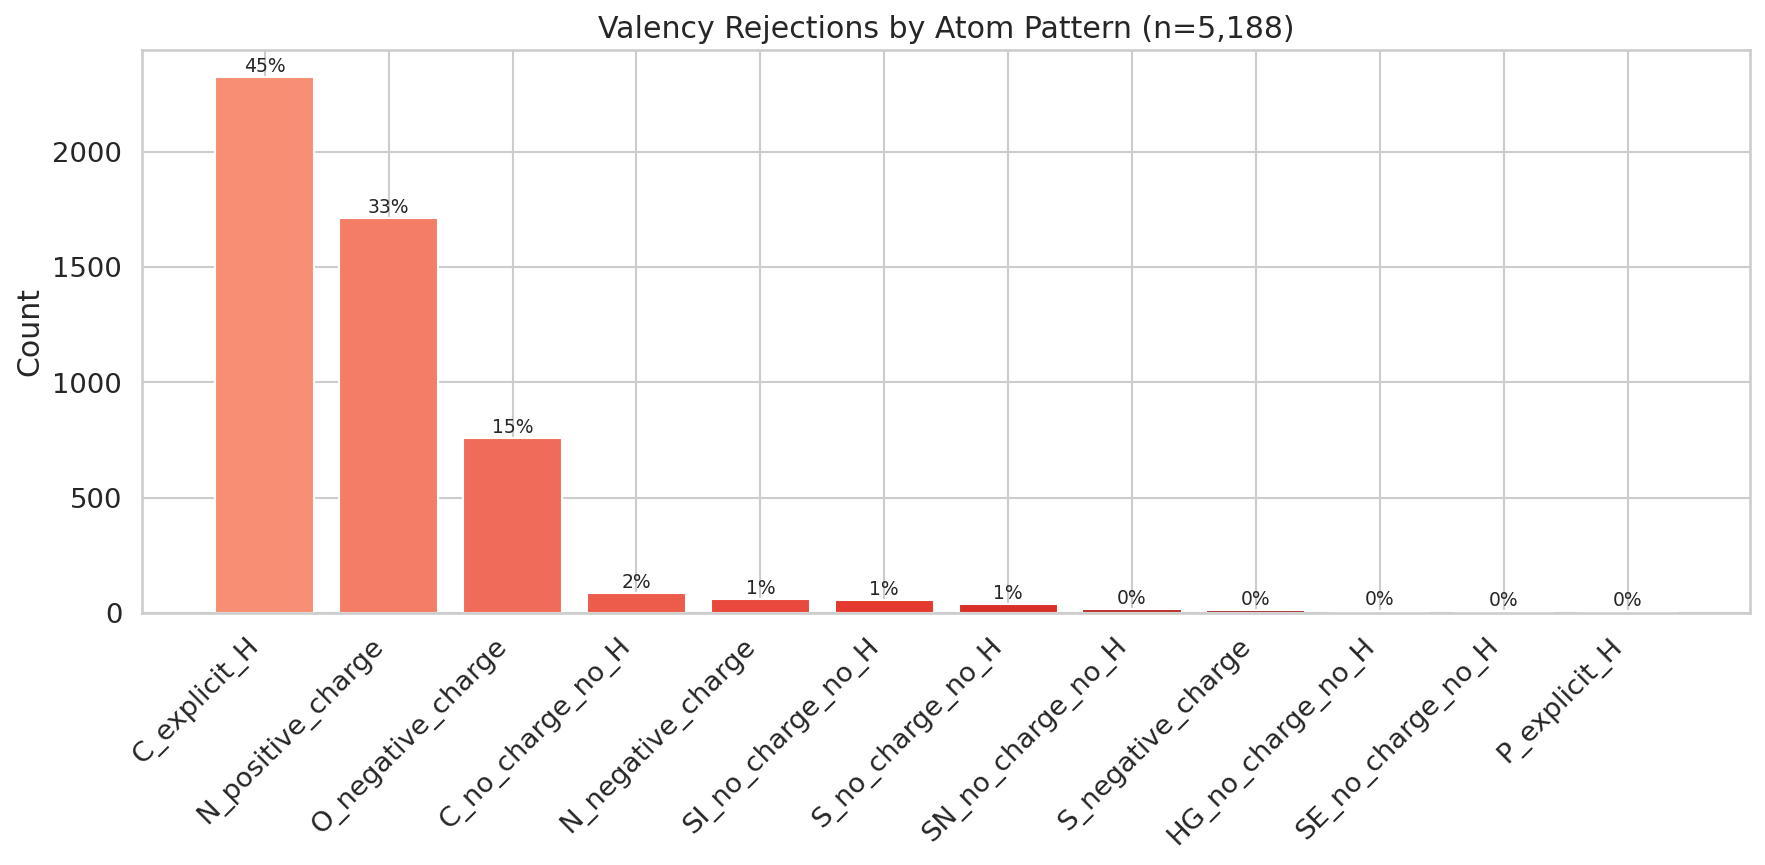

In [24]:
valency_errors = yacc_rejected[yacc_rejected['category'] == 'valency'].copy()

if len(valency_errors) > 0:
    val_subcats = valency_errors['subcategory'].value_counts()
    val_df = pd.DataFrame({
        'Atom Pattern': val_subcats.index,
        'Count': val_subcats.values,
        '%': (val_subcats.values / len(valency_errors) * 100).round(1),
    })
    display(val_df)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    top_val = val_df.head(12)
    bars = ax.bar(top_val['Atom Pattern'], top_val['Count'], 
                  color=sns.color_palette('Reds_d', len(top_val)))
    ax.set_ylabel('Count')
    ax.set_title(f'Valency Rejections by Atom Pattern (n={len(valency_errors):,})')
    plt.xticks(rotation=45, ha='right')
    for bar, pct in zip(bars, top_val['%']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(top_val['Count'])*0.01,
                f'{pct:.0f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No valency errors found.')

In [25]:
# Concrete examples of each valency sub-type
if len(valency_errors) > 0:
    print('Examples of YACC valency rejections (all accepted by RDKit):')
    print('=' * 90)
    for subcat in valency_errors['subcategory'].unique():
        subset = valency_errors[valency_errors['subcategory'] == subcat]
        rdkit_accepts = subset[subset.index.isin(all_df[all_df['RDKit'] == True].index)]
        if len(rdkit_accepts) == 0:
            rdkit_accepts = subset
        print(f'\n  {subcat} ({len(subset)} total)')
        for _, row in rdkit_accepts.head(3).iterrows():
            smi = row['smiles']
            print(f'    SMILES:  {smi[:70]}')
            print(f'    Detail:  {row["detail"]}')
            print(f'    Dataset: {row["dataset"]}')
            print()

Examples of YACC valency rejections (all accepted by RDKit):

  C_explicit_H (2323 total)
    SMILES:  [C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)[O-])O)O
    Detail:  symbol='C', chiral='clockwise', hcount=1
    Dataset: ClinTox

    SMILES:  B([C@H](CC(C)C)NC(=O)[C@H](Cc1ccccc1)NC(=O)c2cnccn2)(O)O
    Detail:  symbol='C', chiral='clockwise', hcount=1
    Dataset: ClinTox

    SMILES:  B([C@H](CC(C)C)NC(=O)[C@H](CC1=CC=CC=C1)NC(=O)C2=NC=CN=C2)(O)O
    Detail:  symbol='C', chiral='clockwise', hcount=1
    Dataset: ClinTox


  bracket_hydrogen (3 total)
    SMILES:  [H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])N)cc2)/C=C1)\N
    Detail:  symbol='H'
    Dataset: ClinTox

    SMILES:  [H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(=[NH+]/[H])/N
    Detail:  symbol='H'
    Dataset: ClinTox

    SMILES:  [H]N=c1n(CC(=O)C(C)(C)C)c2ccccc2n1Cc1ccccc1
    Detail:  symbol='H'
    Dataset: MOSES


  N_positive_charge (1712 total)
    SMILES:  [N+](=O)([O-])[O-]
    Detail:  symbol='N', charge=

### 7c.4. Trailing C Regex — Deep Dive

The pre-check `re.search(r'C$', mol) and re.search(r'\\d', mol)` rejects any SMILES that:
1. Ends with uppercase `C`
2. Contains any digit (indicating a ring closure)

This incorrectly rejects valid molecules like toluene (`c1ccccc1C`), methylcyclohexane (`C1CCCCC1C`), and any molecule with a ring that ends with a methyl carbon.

In [26]:
trailing_c = yacc_rejected[yacc_rejected['category'] == 'trailing_C'].copy()

if len(trailing_c) > 0:
    print(f'Total Trailing C rejections: {len(trailing_c):,}')
    print()
    
    tc_subcats = trailing_c['subcategory'].value_counts()
    display(pd.DataFrame({
        'Sub-type': tc_subcats.index,
        'Count': tc_subcats.values,
    }))
    
    print('\nExamples of valid molecules rejected by trailing C check:')
    print('=' * 80)
    for _, row in trailing_c.head(10).iterrows():
        smi = row['smiles']
        rdkit_ok = validate_rdkit(smi)
        print(f'  {smi[:65]:65s}  RDKit={rdkit_ok}  [{row["dataset"]}]')
    
    tc_rdkit_valid = trailing_c.index.isin(all_df[all_df['RDKit'] == True].index).sum()
    print(f'\nOf {len(trailing_c)} trailing-C rejections, {tc_rdkit_valid} ({tc_rdkit_valid/len(trailing_c)*100:.1f}%) are accepted by RDKit.')
else:
    print('No trailing C rejections found.')

Total Trailing C rejections: 5,154



,Sub-type,Count
0,aromatic_ring+C,3512
1,aliphatic_ring+C,1534
2,other_ring+C,108



Examples of valid molecules rejected by trailing C check:
  C/C=C\1/C(=O)N[C@H](C(=O)O[C@H]\2CC(=O)N[C@@H](C(=O)N[C@H](CSSCC/  RDKit=True  [ClinTox]
  C[C@@](c1ccccc1)(c2ccc(cc2)Cl)OCC[C@H]3CCC[NH+]3C                  RDKit=True  [ClinTox]
  C[C@@]1(C(=O)N2[C@H](C(=O)N3CCC[C@H]3[C@@]2(O1)O)Cc4ccccc4)NC(=O)  RDKit=True  [ClinTox]
  C[C@@]1(C(=O)N2[C@H](C(=O)N3CCC[C@H]3[C@@]2(O1)O)Cc4ccccc4)NC(=O)  RDKit=True  [ClinTox]
  C[C@@H]([C@H](c1ccccc1)O)[NH2+]C                                   RDKit=True  [ClinTox]
  C[C@@H]([NH2+]CC(C[NH2+][C@@H](/C(=N/O)/C)C)(C)C)/C(=N/O)/C        RDKit=True  [ClinTox]
  C[C@@H](CN1c2ccccc2Sc3c1cc(cc3)OC)C[NH+](C)C                       RDKit=True  [ClinTox]
  C[C@@H]1C[C@@H]([C@@H]2[C@H](C[C@H]([C@@](O2)(C(=O)C(=O)N3CCCC[C@  RDKit=True  [ClinTox]
  C[C@@H]1C[C@@H]([C@H]([C@@H](O1)O[C@H]2[C@H](C[C@@]3(CO3)C(=O)[C@  RDKit=True  [ClinTox]
  C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@@]4([C@]3([C@H](C[C@@]2([C  RDKit=True  [ClinTox]

Of 5154 trailing-C rejections,

### 7c.5. Aromaticity (Hückel) Errors — Deep Dive

In [27]:
arom_errors = yacc_rejected[yacc_rejected['category'] == 'huckel'].copy()

if len(arom_errors) > 0:
    print(f'Total Hückel rejections: {len(arom_errors):,}')
    
    arom_subcats = arom_errors['subcategory'].value_counts()
    display(pd.DataFrame({
        'Aromatic Atom Count': arom_subcats.index,
        'Count': arom_subcats.values,
    }))
    
    print('\nExamples of Hückel rejections:')
    print('=' * 80)
    for _, row in arom_errors.head(10).iterrows():
        smi = row['smiles']
        rdkit_ok = validate_rdkit(smi)
        print(f'  {smi[:65]:65s}  RDKit={rdkit_ok}  [{row["dataset"]}]')
else:
    print('No Hückel rejections found.')

Total Hückel rejections: 11,102


,Aromatic Atom Count,Count
0,12_aromatic_atoms,2524
1,11_aromatic_atoms,1890
2,6_aromatic_atoms,1320
3,17_aromatic_atoms,843
4,16_aromatic_atoms,695
5,15_aromatic_atoms,563
6,13_aromatic_atoms,489
7,5_aromatic_atoms,476
8,18_aromatic_atoms,457
9,10_aromatic_atoms,347



Examples of Hückel rejections:
  C([C@@H]1[C@H]([C@@H]([C@H](C(=O)O1)O)O)O)O                        RDKit=True  [ClinTox]
  c1[nH]c2c(n1)[nH]c(nc2=S)N                                         RDKit=True  [ClinTox]
  c1[nH]c2c(n1)[nH]cnc2=S                                            RDKit=True  [ClinTox]
  c1c(c([nH]c(=O)n1)N)F                                              RDKit=True  [ClinTox]
  c1c(c(=O)[nH]c(=O)[nH]1)F                                          RDKit=True  [ClinTox]
  c1c(c(=O)[nH]c(=O)[nH]1)N(CCCl)CCCl                                RDKit=True  [ClinTox]
  c1c(c(=O)[nH]c(=O)n1[C@H]2C[C@@H]([C@H](O2)CO)O)C(F)(F)F           RDKit=True  [ClinTox]
  c1c(c(=O)[nH]c(=O)n1[C@H]2C[C@@H]([C@H](O2)CO)O)F                  RDKit=True  [ClinTox]
  c1c(c(=O)[nH]c(=O)n1[C@H]2C[C@@H]([C@H](O2)CO)O)I                  RDKit=True  [ClinTox]
  C1=C(C(=O)NC(=O)N1)F                                               RDKit=True  [ClinTox]


### 7c.6. Syntax Parsing Errors

In [28]:
syntax_errors = yacc_rejected[yacc_rejected['stage'] == 'syntax'].copy()

if len(syntax_errors) > 0:
    print(f'Total syntax rejections: {len(syntax_errors):,}')
    
    syn_subcats = syntax_errors.groupby(['category', 'subcategory']).size().reset_index(name='count')
    syn_subcats = syn_subcats.sort_values('count', ascending=False)
    display(syn_subcats)
    
    print('\nExamples of syntax rejections:')
    print('=' * 80)
    for _, row in syntax_errors.head(10).iterrows():
        smi = row['smiles']
        rdkit_ok = validate_rdkit(smi)
        print(f'  {smi[:55]:55s}  RDKit={rdkit_ok}  cat={row["subcategory"]}  [{row["dataset"]}]')
    
    syn_both_reject = syntax_errors.index.isin(all_df[all_df['RDKit'] == False].index).sum()
    print(f'\nOf {len(syntax_errors)} syntax rejections, {syn_both_reject} ({syn_both_reject/len(syntax_errors)*100:.1f}%) are also rejected by RDKit.')
else:
    print('No syntax errors found.')

Total syntax rejections: 695


,category,subcategory,count
0,chain_error,dot_proxy,694
1,illegal_char,wildcard_atom,1



Examples of syntax rejections:
  *C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC                  RDKit=True  cat=wildcard_atom  [ClinTox]
  C1C(N(C2=C(N1)NC(=NC2=O)N)C=O)CNC3=CC=C(C=C3)C(=O)N[C@@  RDKit=True  cat=dot_proxy  [ClinTox]
  C1CC(C1)(C(=O)O)C(=O)O.N.N.[Pt]                          RDKit=True  cat=dot_proxy  [ClinTox]
  C1=CN(C(=O)N=C1N)[C@H]2C([C@@H]([C@H](O2)CO)O)(F)F.Cl    RDKit=True  cat=dot_proxy  [ClinTox]
  C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC3=C(C4=C(  RDKit=True  cat=dot_proxy  [ClinTox]
  C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC3=C(C4=C(  RDKit=True  cat=dot_proxy  [ClinTox]
  CC(C(=O)O)O.CN1CCN(CC1)C2=CC3=C(C=C2)N/C(=C\4/C(=C5C(=N  RDKit=True  cat=dot_proxy  [ClinTox]
  CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=C  RDKit=True  cat=dot_proxy  [ClinTox]
  CC1=CC=C(C=C1)S(=O)(=O)O.CNC(=O)C1=NC=CC(=C1)OC2=CC=C(C  RDKit=True  cat=dot_proxy  [ClinTox]
  CC[C@@]1(C[C@@H]2C[C@@](C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C  RDKit=True  cat=dot_proxy  [ClinTox]

Of 

### 7c.7. Syntax-Only vs Full Validation

Comparing `parse_smiles` (syntax only) against `validate_smiles` (syntax + chemistry) to separate parsing failures from chemistry-check rejections.

In [29]:
def validate_yacc_syntax_only(mol):
    status, _, _ = parse_smiles(mol)
    return status

print('Running syntax-only validation...', flush=True)
all_df['YACC_syntax'] = all_df['smiles'].apply(validate_yacc_syntax_only)
print('Done.')

syntax_pass = all_df['YACC_syntax'].sum()
full_pass = all_df['YACC'].sum()
chem_rejections = syntax_pass - full_pass

print(f'\nSyntax-only pass:  {syntax_pass:>7,} ({syntax_pass/len(all_df)*100:.1f}%)')
print(f'Full pass:         {full_pass:>7,} ({full_pass/len(all_df)*100:.1f}%)')
print(f'Syntax failures:   {len(all_df) - syntax_pass:>7,} ({(len(all_df)-syntax_pass)/len(all_df)*100:.1f}%)')
print(f'Chemistry-only:    {chem_rejections:>7,} ({chem_rejections/len(all_df)*100:.1f}%)')
print(f'  (molecules that parse OK but fail chemistry checks)')

Running syntax-only validation...


Done.

Syntax-only pass:   54,328 (98.7%)
Full pass:          32,892 (59.8%)
Syntax failures:       704 (1.3%)
Chemistry-only:     21,436 (39.0%)
  (molecules that parse OK but fail chemistry checks)


In [30]:
syntax_fail = all_df['YACC_syntax'] == False
chem_fail = (all_df['YACC_syntax'] == True) & (all_df['YACC'] == False)
both_pass = (all_df['YACC_syntax'] == True) & (all_df['YACC'] == True)

groups = {
    'Syntax Fail': all_df[syntax_fail],
    'Chemistry Fail Only': all_df[chem_fail],
    'Both Pass': all_df[both_pass],
}

print(f'{"Group":<25} {"Count":>7} {"RDKit Accepts":>15} {"RDKit Rejects":>15}')
print('-' * 65)
for name, group in groups.items():
    rdkit_ok = group['RDKit'].sum()
    rdkit_no = len(group) - rdkit_ok
    print(f'{name:<25} {len(group):>7,} {rdkit_ok:>15,} {rdkit_no:>15,}')

Group                       Count   RDKit Accepts   RDKit Rejects
-----------------------------------------------------------------
Syntax Fail                   704             704               0
Chemistry Fail Only        21,436          21,429               7
Both Pass                  32,892          32,888               4


### 7c.8. Error Distribution Across Datasets

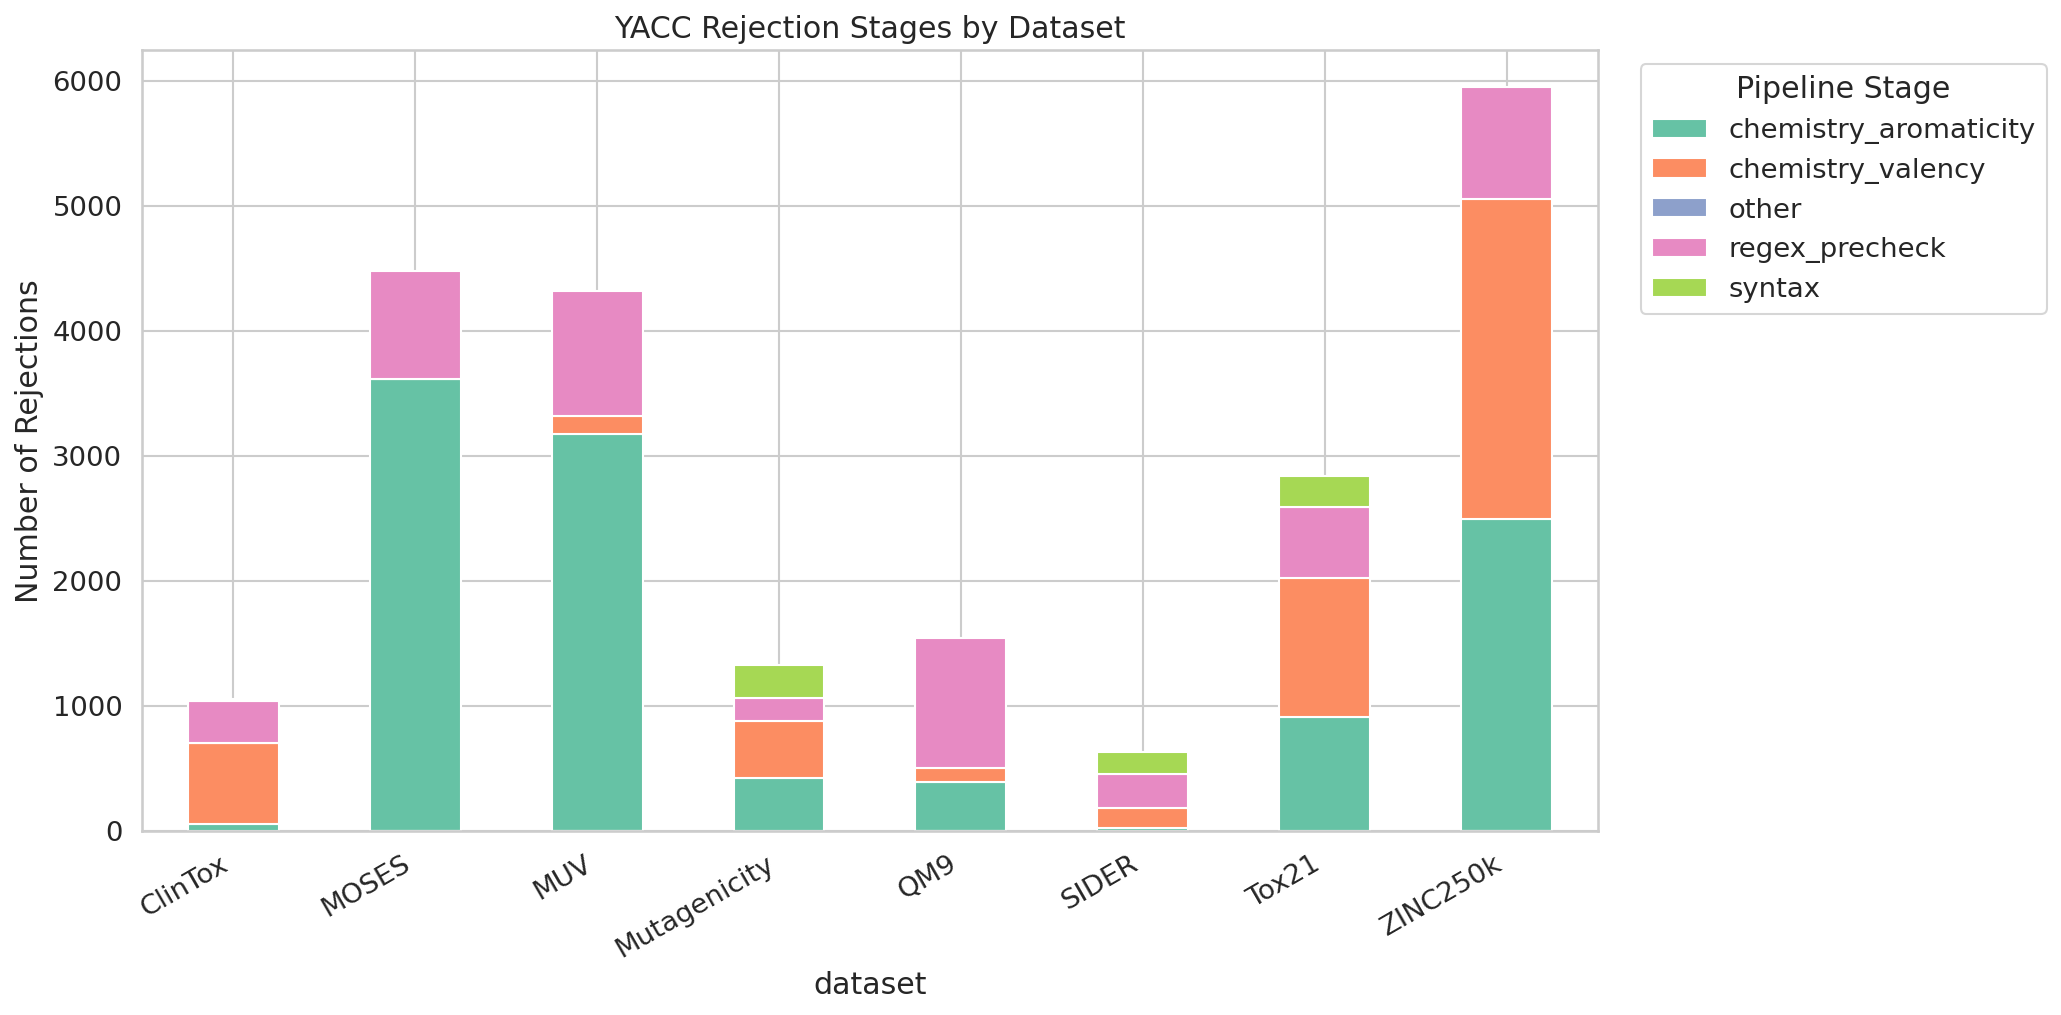

Rejection stage distribution (% within each dataset):


stage,chemistry_aromaticity,chemistry_valency,other,regex_precheck,syntax
dataset,,,,,
ClinTox,5.6,61.0,0.1,31.9,1.4
MOSES,80.7,0.0,0.0,19.3,0.0
MUV,73.5,3.4,0.0,23.1,0.0
Mutagenicity,31.7,34.8,0.0,13.7,19.9
QM9,25.7,7.3,0.0,67.1,0.0
SIDER,4.4,24.9,0.0,43.1,27.6
Tox21,32.1,39.3,0.0,20.1,8.5
ZINC250k,42.0,42.9,0.0,15.1,0.0


In [31]:
error_by_dataset = yacc_rejected.groupby(['dataset', 'stage']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
error_by_dataset.plot(kind='bar', stacked=True, ax=ax, 
                       color=sns.color_palette('Set2', error_by_dataset.shape[1]))
ax.set_ylabel('Number of Rejections')
ax.set_title('YACC Rejection Stages by Dataset')
ax.legend(title='Pipeline Stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

error_pct = error_by_dataset.div(error_by_dataset.sum(axis=1), axis=0) * 100
print('Rejection stage distribution (% within each dataset):')
display(error_pct.round(1))

### 7c.9. Molecules YACC Uniquely Accepts (YACC Valid, RDKit Invalid)

In [32]:
yacc_unique = all_df[(all_df['YACC'] == True) & (all_df['RDKit'] == False)].copy()
print(f'YACC accepts but RDKit rejects: {len(yacc_unique)} molecules\n')

if len(yacc_unique) > 0:
    for _, row in yacc_unique.iterrows():
        smi = row['smiles']
        other_results = {v: row[v] for v in validator_names if v not in ['YACC', 'RDKit']}
        print(f'  SMILES:  {smi}')
        print(f'  Dataset: {row["dataset"]}')
        print(f'  Others:  {other_results}')
        print()

YACC accepts but RDKit rejects: 4 molecules

  SMILES:  c1ccc(cc1)n2c(=O)c(c(=O)n2c3ccccc3)CCS(=O)c4ccccc4
  Dataset: ClinTox
  Others:  {'PartialSMILES': False, 'PySMILES': False, 'MolVS': False}

  SMILES:  CCCCc1c(=O)n(n(c1=O)c2ccc(cc2)O)c3ccccc3
  Dataset: ClinTox
  Others:  {'PartialSMILES': False, 'PySMILES': False, 'MolVS': False}

  SMILES:  CCCCc1c(=O)n(n(c1=O)c2ccccc2)c3ccccc3
  Dataset: ClinTox
  Others:  {'PartialSMILES': False, 'PySMILES': False, 'MolVS': False}

  SMILES:  NC(=O)NC1N=C(O[AlH3](O)O)NC1=O
  Dataset: Tox21
  Others:  {'PartialSMILES': False, 'PySMILES': False, 'MolVS': False}



### 7c.10. Summary of Error Analysis

In [33]:
total_rejected = len(yacc_rejected)
total_mols = len(all_df)
rdkit_also_rejects = yacc_rejected.index.isin(all_df[all_df['RDKit'] == False].index).sum()
false_rejections = total_rejected - rdkit_also_rejects

print('=' * 70)
print('YACC ERROR ANALYSIS SUMMARY')
print('=' * 70)
print(f'Total molecules:     {total_mols:>7,}')
print(f'YACC rejections:     {total_rejected:>7,} ({total_rejected/total_mols*100:.1f}%)')
print(f'  Also rejected by RDKit: {rdkit_also_rejects:>5,} (true negatives or shared strictness)')
print(f'  YACC-only rejections:   {false_rejections:>5,} (potential false negatives)')
print()
print('Breakdown of YACC-only rejections by stage:')
yacc_only_rejections = yacc_rejected[~yacc_rejected.index.isin(all_df[all_df['RDKit'] == False].index)]
if len(yacc_only_rejections) > 0:
    stage_breakdown = yacc_only_rejections['stage'].value_counts()
    for stage, count in stage_breakdown.items():
        pct = count / len(yacc_only_rejections) * 100
        print(f'  {stage:<30} {count:>6,} ({pct:.1f}%)')
    
    print()
    print('Top sub-categories of YACC-only rejections:')
    subcat_breakdown = yacc_only_rejections.groupby(['category', 'subcategory']).size().sort_values(ascending=False)
    for (cat, subcat), count in subcat_breakdown.head(10).items():
        pct = count / len(yacc_only_rejections) * 100
        print(f'  {cat}/{subcat:<35} {count:>6,} ({pct:.1f}%)')

print()
print('Recommended fixes (ordered by impact):')
if len(yacc_only_rejections) > 0:
    for stage, count in yacc_only_rejections['stage'].value_counts().items():
        if stage == 'chemistry_valency':
            print(f'  1. Fix valency check for charged bracket atoms ({count:,} molecules affected)')
            print('     -> [O-], [N+], [NH4+], [H] with bonds all fail compute_valency()')
        elif stage == 'regex_precheck':
            print(f'  2. Remove/fix trailing C regex ({count:,} molecules affected)')
            print('     -> c1ccccc1C (toluene) is incorrectly rejected')
        elif stage == 'chemistry_aromaticity':
            print(f'  3. Review Huckel rule edge cases ({count:,} molecules affected)')
        elif stage == 'syntax':
            print(f'  4. Extend parser for unsupported syntax ({count:,} molecules affected)')
            print('     -> wildcard atoms (*), some bracket atom patterns')

YACC ERROR ANALYSIS SUMMARY
Total molecules:      55,032
YACC rejections:      22,140 (40.2%)
  Also rejected by RDKit:     7 (true negatives or shared strictness)
  YACC-only rejections:   22,133 (potential false negatives)

Breakdown of YACC-only rejections by stage:
  chemistry_aromaticity          11,102 (50.2%)
  chemistry_valency               5,183 (23.4%)
  regex_precheck                  5,152 (23.3%)
  syntax                            695 (3.1%)
  other                               1 (0.0%)

Top sub-categories of YACC-only rejections:
  trailing_C/aromatic_ring+C                      3,512 (15.9%)
  huckel/12_aromatic_atoms                    2,524 (11.4%)
  valency/C_explicit_H                         2,323 (10.5%)
  huckel/11_aromatic_atoms                    1,890 (8.5%)
  valency/N_positive_charge                    1,712 (7.7%)
  trailing_C/aliphatic_ring+C                     1,534 (6.9%)
  huckel/6_aromatic_atoms                     1,320 (6.0%)
  huckel/17_aromatic_

## 8. Statistical Tests

### 8a. McNemar's Test (Pairwise)

Tests whether two validators have significantly different error rates. Uses RDKit as the reference (most widely used tool).

In [34]:
def mcnemar_test(y1, y2):
    """McNemar's test for paired binary data.
    Returns chi2, p-value.
    y1/y2: boolean arrays of same length.
    """
    b = ((y1 == True) & (y2 == False)).sum()  # y1 correct, y2 wrong
    c = ((y1 == False) & (y2 == True)).sum()   # y2 correct, y1 wrong
    if b + c == 0:
        return 0.0, 1.0
    # With continuity correction
    chi2 = (abs(b - c) - 1)**2 / (b + c)
    p = 1 - stats.chi2.cdf(chi2, df=1)
    return chi2, p

# McNemar's test: each validator vs RDKit
mcnemar_results = []
for name in validator_names:
    if name == 'RDKit':
        continue
    chi2, p = mcnemar_test(all_df[name], all_df['RDKit'])
    mcnemar_results.append({
        'Validator': name,
        'vs': 'RDKit',
        'chi2': round(chi2, 2),
        'p-value': f'{p:.2e}' if p < 0.001 else f'{p:.4f}',
        'Significant (p<0.05)': p < 0.05,
    })

display(pd.DataFrame(mcnemar_results))

,Validator,vs,chi2,p-value,Significant (p<0.05)
0,YACC,RDKit,22119.00,0.00e+00,True
1,PartialSMILES,RDKit,162.01,0.00e+00,True
2,PySMILES,RDKit,1359.01,0.00e+00,True
3,MolVS,RDKit,4669.00,0.00e+00,True


### 8b. Cochran's Q Test

Tests whether there is a significant difference among all validators simultaneously.

In [35]:
def cochrans_q(data_matrix):
    """Cochran's Q test for k related binary samples.
    data_matrix: (n_subjects, k_validators) boolean array.
    """
    k = data_matrix.shape[1]
    n = data_matrix.shape[0]

    # Column totals
    T_j = data_matrix.sum(axis=0)
    # Row totals
    L_i = data_matrix.sum(axis=1)

    T_grand = T_j.sum()

    numerator = (k - 1) * (k * (T_j**2).sum() - T_grand**2)
    denominator = k * T_grand - (L_i**2).sum()

    if denominator == 0:
        return 0.0, 1.0

    Q = numerator / denominator
    p = 1 - stats.chi2.cdf(Q, df=k-1)
    return Q, p

# Build matrix
val_matrix = all_df[validator_names].values.astype(int)
Q, p = cochrans_q(val_matrix)
print(f"Cochran's Q = {Q:.2f}")
print(f"p-value = {p:.2e}")
print(f"Significant difference among validators: {'Yes' if p < 0.05 else 'No'}")

Cochran's Q = 67655.57
p-value = 0.00e+00
Significant difference among validators: Yes


## 9. Performance Benchmarks

In [36]:
# Benchmark on a fixed subset
bench_sample = all_df['smiles'].sample(n=min(5000, len(all_df)), random_state=SEED).tolist()

perf_results = []
for name, validator in VALIDATORS.items():
    times = []
    # Run 3 times for stability
    for trial in range(3):
        start = time.time()
        for smi in bench_sample:
            validator(smi)
        elapsed = time.time() - start
        times.append(elapsed)
    avg_time = np.mean(times)
    std_time = np.std(times)
    per_mol = avg_time / len(bench_sample) * 1000  # ms per molecule
    throughput = len(bench_sample) / avg_time
    perf_results.append({
        'Validator': name,
        'Total (s)': round(avg_time, 2),
        'Std (s)': round(std_time, 3),
        'Per Molecule (ms)': round(per_mol, 3),
        'Throughput (mol/s)': int(throughput),
    })

perf_df = pd.DataFrame(perf_results).sort_values('Per Molecule (ms)')
display(perf_df)

[17:56:11] Explicit valence for atom # 9 Al, 6, is greater than permitted
[17:56:11] Can't kekulize mol.  Unkekulized atoms: 4
[17:56:11] Explicit valence for atom # 4 Al, 6, is greater than permitted


[17:56:11] Explicit valence for atom # 9 Al, 6, is greater than permitted
[17:56:11] Can't kekulize mol.  Unkekulized atoms: 4
[17:56:11] Explicit valence for atom # 4 Al, 6, is greater than permitted


[17:56:11] Explicit valence for atom # 9 Al, 6, is greater than permitted
[17:56:11] Can't kekulize mol.  Unkekulized atoms: 4
[17:56:11] Explicit valence for atom # 4 Al, 6, is greater than permitted


[17:56:38] Explicit valence for atom # 9 Al, 6, is greater than permitted


[17:56:41] Can't kekulize mol.  Unkekulized atoms: 4


...

[17:57:11] Explicit valence for atom # 4 Al, 6, is greater than permitted


[17:57:22] Explicit valence for atom # 9 Al, 6, is greater than permitted


[17:57:25] Can't kekulize mol.  Unkekulized atoms: 4


[17:57:35] Explicit valence for atom # 4 Al, 6, is greater than permitted


,Validator,Total (s),Std (s),Per Molecule (ms),Throughput (mol/s)
1,RDKit,0.26,0.001,0.052,19258
2,PartialSMILES,0.47,0.001,0.094,10657
0,YACC,2.45,0.009,0.489,2043
3,PySMILES,7.28,0.327,1.456,686
4,MolVS,22.40,1.458,4.480,223


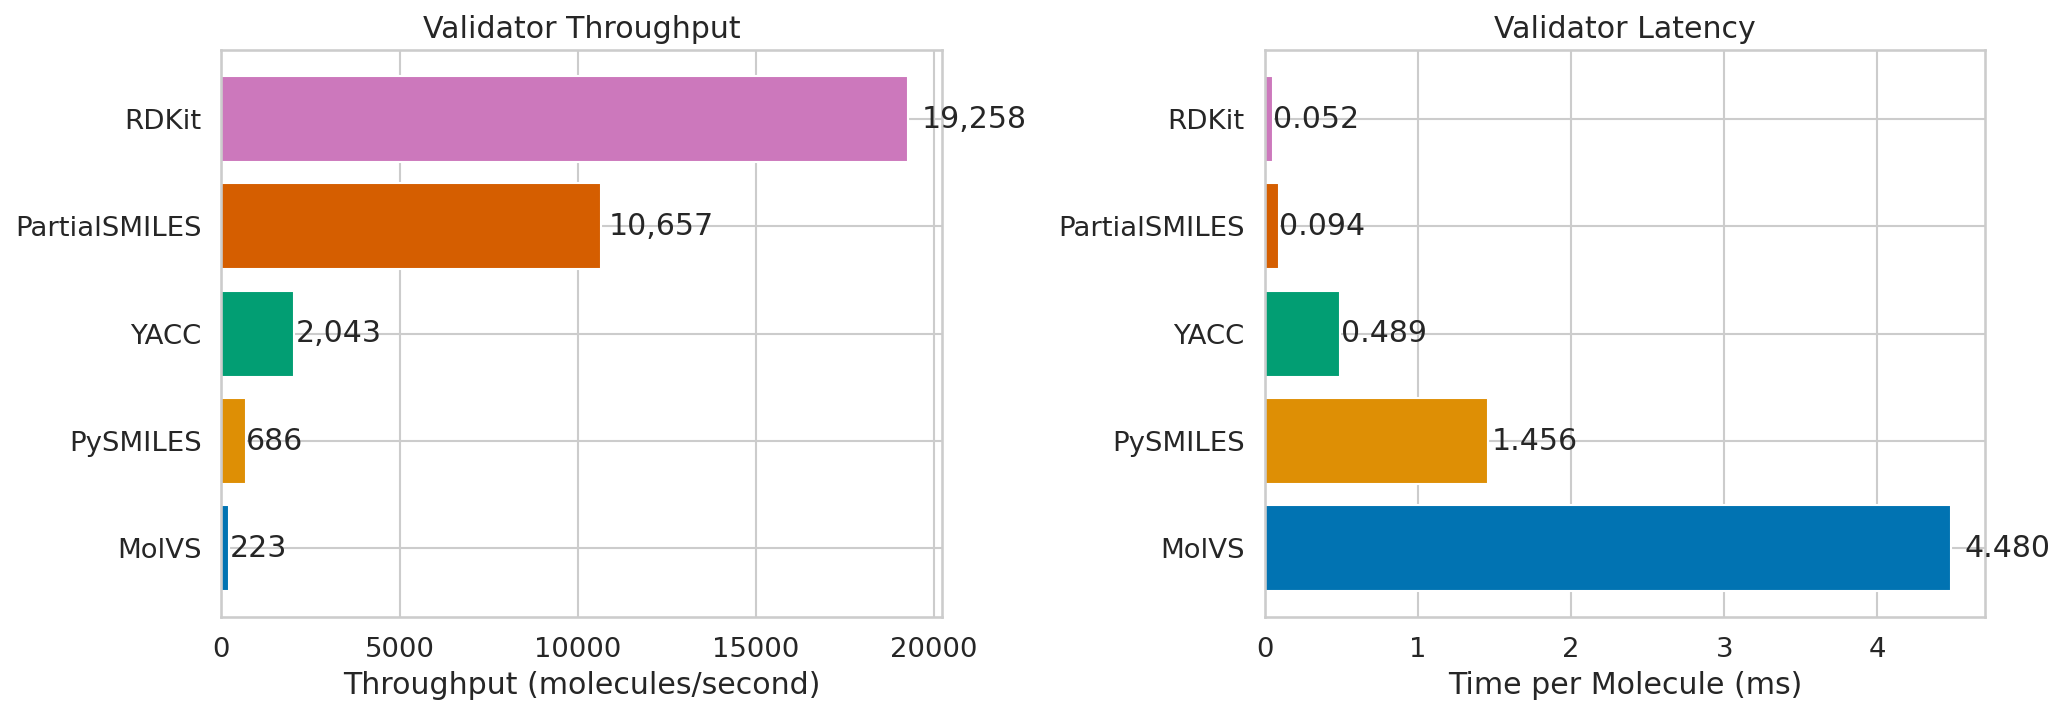

In [37]:
# Performance bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_perf = sns.color_palette('colorblind', len(perf_df))

# Throughput
perf_sorted = perf_df.sort_values('Throughput (mol/s)', ascending=True)
axes[0].barh(perf_sorted['Validator'], perf_sorted['Throughput (mol/s)'], color=colors_perf)
axes[0].set_xlabel('Throughput (molecules/second)')
axes[0].set_title('Validator Throughput')
for i, (_, row) in enumerate(perf_sorted.iterrows()):
    axes[0].text(row['Throughput (mol/s)'] * 1.02, i, f"{row['Throughput (mol/s)']:,}", va='center')

# Per molecule time
perf_sorted2 = perf_df.sort_values('Per Molecule (ms)', ascending=False)
axes[1].barh(perf_sorted2['Validator'], perf_sorted2['Per Molecule (ms)'], color=colors_perf)
axes[1].set_xlabel('Time per Molecule (ms)')
axes[1].set_title('Validator Latency')
for i, (_, row) in enumerate(perf_sorted2.iterrows()):
    axes[1].text(row['Per Molecule (ms)'] * 1.02, i, f"{row['Per Molecule (ms)']:.3f}", va='center')

plt.tight_layout()

plt.show()

## 10. Confusion Matrices (Ground Truth)

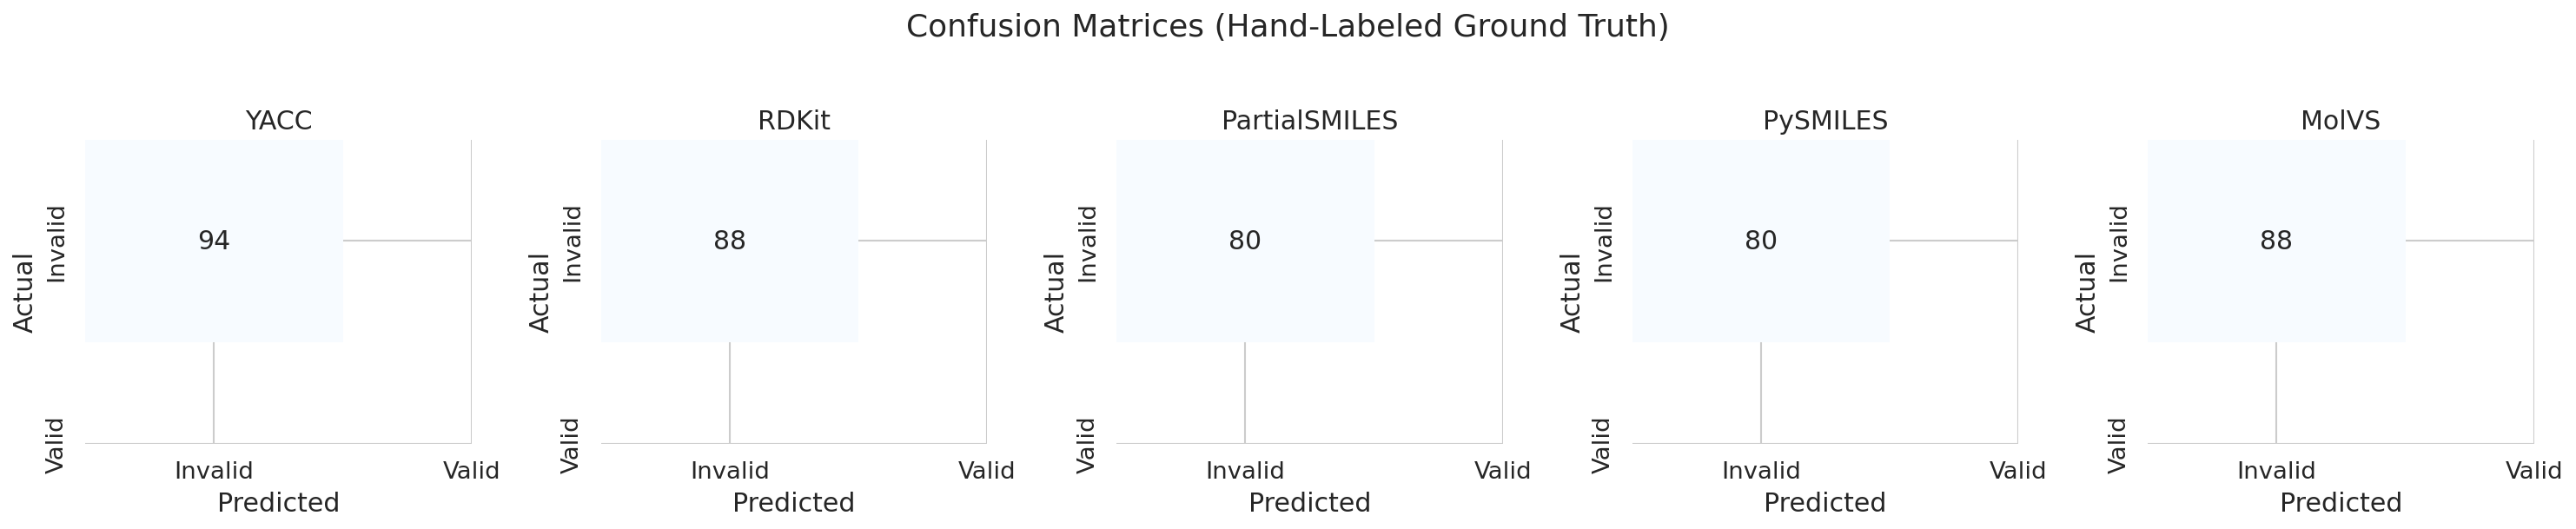

In [38]:
fig, axes = plt.subplots(1, len(VALIDATORS), figsize=(4*len(VALIDATORS), 4))

for ax, name in zip(axes, VALIDATORS.keys()):
    cm = pd.crosstab(gt_df['ground_truth'], gt_df[name],
                     rownames=['Actual'], colnames=['Predicted'])
    # Ensure 2x2 matrix
    for idx in [False, True]:
        if idx not in cm.index:
            cm.loc[idx] = 0
        if idx not in cm.columns:
            cm[idx] = 0
    cm = cm.loc[[False, True], [False, True]]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Invalid', 'Valid'], yticklabels=['Invalid', 'Valid'])
    ax.set_title(name)

plt.suptitle('Confusion Matrices (Hand-Labeled Ground Truth)', y=1.02)
plt.tight_layout()

plt.show()

## 11. SMILES Complexity Analysis

How does YACC's acceptance rate vary with molecular complexity (SMILES length, number of rings, aromatic atoms)?

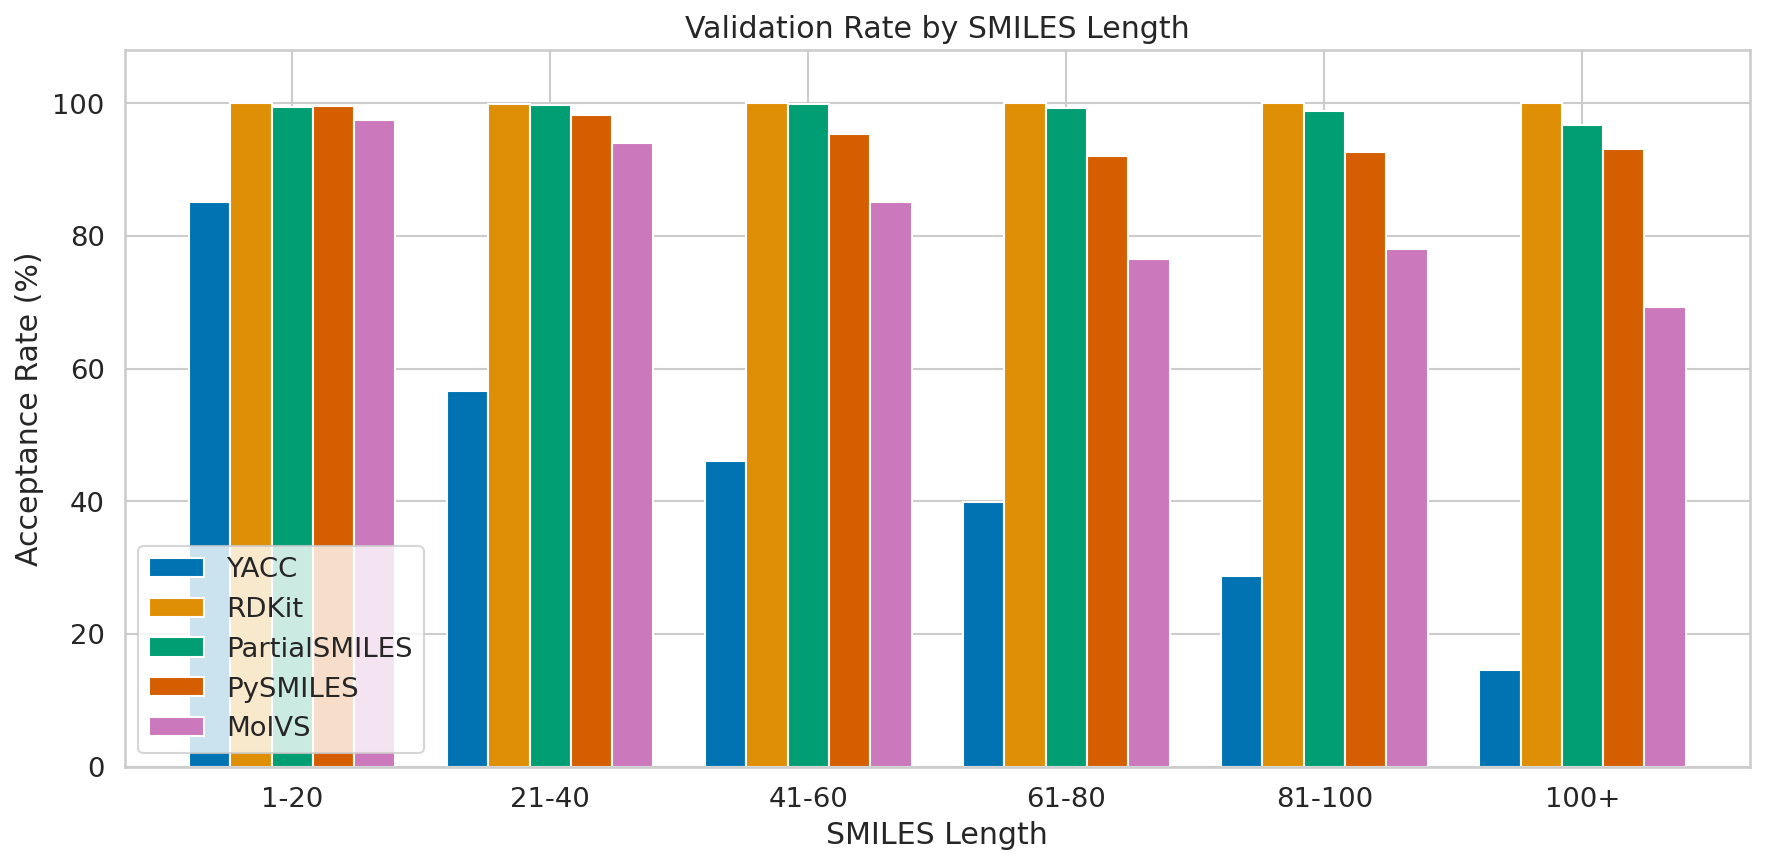

In [39]:
all_df['smi_len'] = all_df['smiles'].str.len()
all_df['n_rings'] = all_df['smiles'].str.count(r'\d')  # rough proxy for ring closures
all_df['n_aromatic'] = all_df['smiles'].str.count(r'[a-z]')  # lowercase = aromatic
all_df['has_brackets'] = all_df['smiles'].str.contains(r'\[').astype(int)

# Bin SMILES by length
all_df['len_bin'] = pd.cut(all_df['smi_len'], bins=[0, 20, 40, 60, 80, 100, 300],
                            labels=['1-20', '21-40', '41-60', '61-80', '81-100', '100+'])

# Acceptance rate by length bin
len_rates = all_df.groupby('len_bin', observed=True)[validator_names].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
len_rates.plot(kind='bar', ax=ax, width=0.8, color=sns.color_palette('colorblind', len(validator_names)))
ax.set_ylabel('Acceptance Rate (%)')
ax.set_xlabel('SMILES Length')
ax.set_title('Validation Rate by SMILES Length')
ax.legend(loc='lower left')
ax.set_ylim(0, 108)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

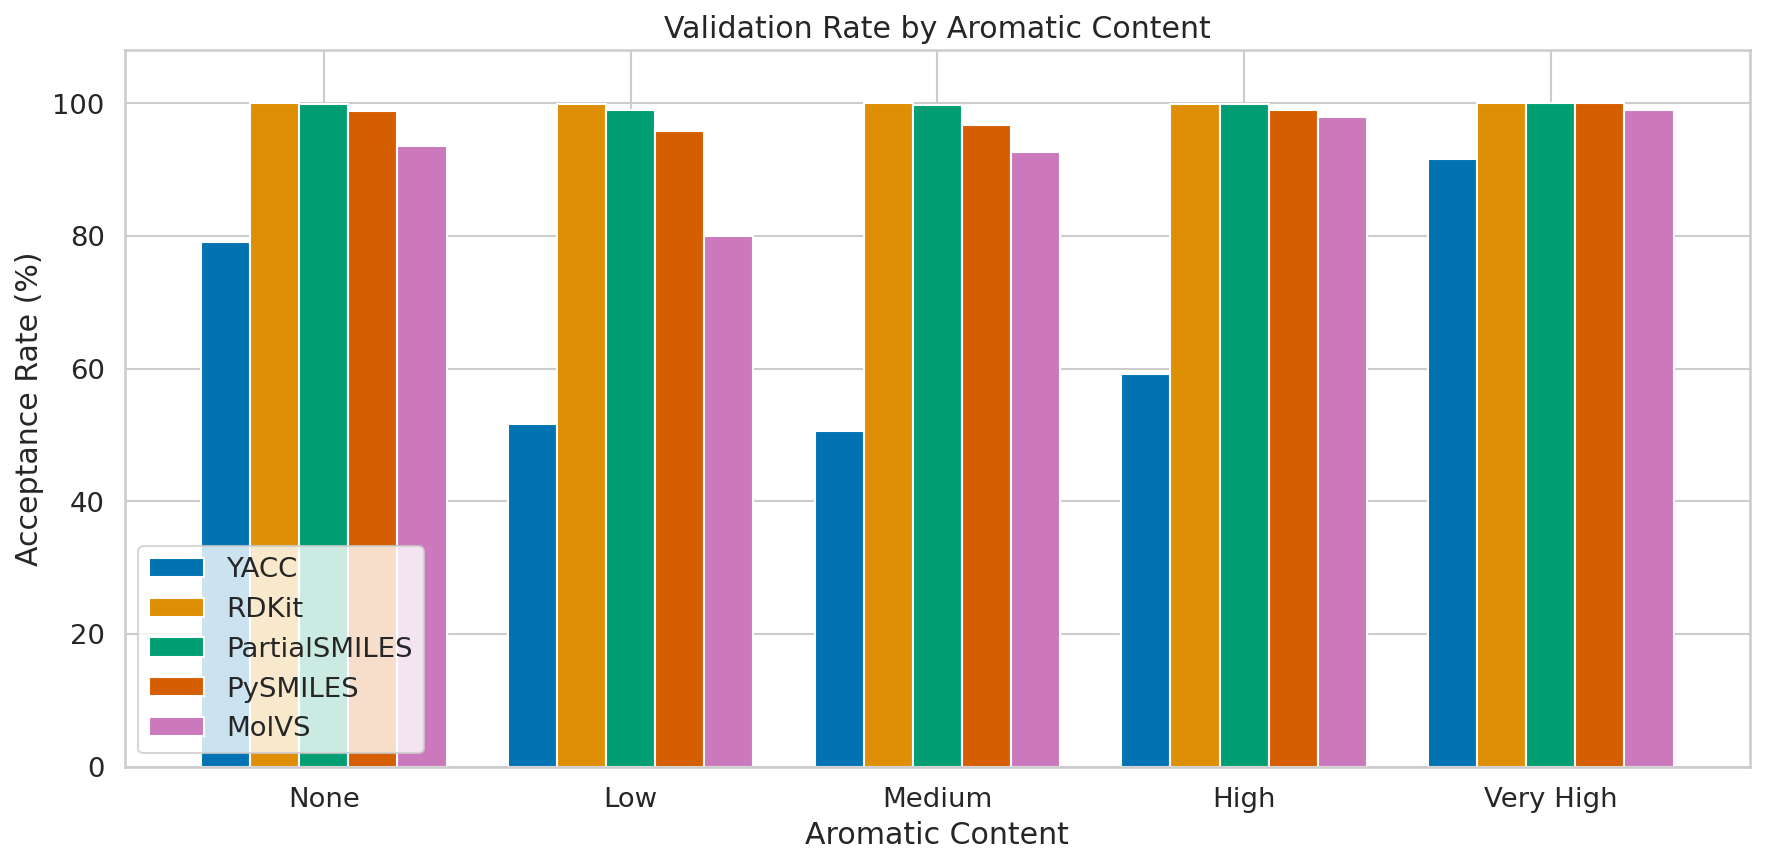

In [40]:
# Acceptance rate by aromatic content
all_df['aromatic_ratio'] = all_df['n_aromatic'] / all_df['smi_len']
all_df['arom_bin'] = pd.cut(all_df['aromatic_ratio'], bins=[0, 0.01, 0.2, 0.4, 0.6, 1.0],
                             labels=['None', 'Low', 'Medium', 'High', 'Very High'],
                             include_lowest=True)

arom_rates = all_df.groupby('arom_bin', observed=True)[validator_names].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
arom_rates.plot(kind='bar', ax=ax, width=0.8, color=sns.color_palette('colorblind', len(validator_names)))
ax.set_ylabel('Acceptance Rate (%)')
ax.set_xlabel('Aromatic Content')
ax.set_title('Validation Rate by Aromatic Content')
ax.legend(loc='lower left')
ax.set_ylim(0, 108)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 12. Summary

In [41]:
print('=' * 70)
print('COMPREHENSIVE VALIDATION SUMMARY')
print('=' * 70)
print(f'Total molecules evaluated: {len(all_df):,}')
print(f'Datasets: {len(datasets)}')
print(f'Validators: {len(VALIDATORS)}')
print()

print('── Overall Pass Rates ──')
for _, row in overall_df.iterrows():
    print(f"  {row['Validator']:15} {row['Pass Rate (%)']:6.2f}%  ({row['Molecules Accepted']:,} accepted)")

print()
print('── Ground Truth F1 (Hand-Labeled, n={}) ──'.format(len(gt_df)))
for _, row in gt_metrics_df.iterrows():
    print(f"  {row['Validator']:15} F1={row['F1']}  {row['F1 95% CI']}")

print()
print('── Invalid SMILES Detection ──')
for _, row in inv_det_df.iterrows():
    print(f"  {row['Validator']:15} {row['Detection Rate (%)']:5.1f}% detected ({row['Rejected']}/{row['Rejected']+row['Missed']})")

print()
print('── Performance ──')
for _, row in perf_df.iterrows():
    print(f"  {row['Validator']:15} {row['Per Molecule (ms)']:.3f} ms/mol  ({row['Throughput (mol/s)']:,} mol/s)")

print()
print('── Key Findings ──')
yacc_rate = overall['YACC']
rdkit_rate = overall['RDKit']
print(f'  YACC accepts {yacc_rate:.1f}% vs RDKit {rdkit_rate:.1f}% of benchmark molecules.')
if len(rdkit_only) > 0:
    print(f'  YACC rejects {len(rdkit_only):,} molecules that RDKit accepts.')
if len(yacc_only) > 0:
    print(f'  YACC accepts {len(yacc_only):,} molecules that RDKit rejects.')
print(f"  Cochran's Q test: p={p:.2e} — validators differ significantly." if p < 0.05 else f"  Cochran's Q test: p={p:.4f} — no significant difference.")

COMPREHENSIVE VALIDATION SUMMARY
Total molecules evaluated: 55,032
Datasets: 8
Validators: 5

── Overall Pass Rates ──
  RDKit            99.98%  (55,021 accepted)
  PartialSMILES    99.68%  (54,857 accepted)
  PySMILES         97.50%  (53,658 accepted)
  MolVS            91.49%  (50,350 accepted)
  YACC             59.77%  (32,892 accepted)

── Ground Truth F1 (Hand-Labeled, n=126) ──
  YACC            F1=100.00%  [1.000, 1.000]
  RDKit           F1=86.70%  [0.816, 0.915]
  MolVS           F1=86.70%  [0.816, 0.915]
  PartialSMILES   F1=82.05%  [0.759, 0.876]
  PySMILES        F1=82.05%  [0.759, 0.876]

── Invalid SMILES Detection ──
  MolVS            90.4% detected (47/52)
  PartialSMILES    88.5% detected (46/52)
  YACC             82.7% detected (43/52)
  RDKit            80.8% detected (42/52)
  PySMILES         55.8% detected (29/52)

── Performance ──
  RDKit           0.052 ms/mol  (19,258 mol/s)
  PartialSMILES   0.094 ms/mol  (10,657 mol/s)
  YACC            0.489 ms/mol  (2,

In [42]:
# Export results for further analysis
all_df.to_parquet('validation_results_full.parquet', index=False)
print(f'Results exported to validation_results_full.parquet ({len(all_df):,} rows)')

Results exported to validation_results_full.csv (55,032 rows)
